# Notebook 3 — Model Training & Evaluation
**Dataset:** 1000 samples, 9 features, 4 targets

Four model families trained and compared against the physics engine:
Ridge/Lasso · Logistic Regression · SVM/SVR · Random Forest · ANN (PyTorch)
All regression models use 5-fold KFold CV; classification uses StratifiedKFold.
ANN uses a custom PyTorch k-fold loop to keep it on equal footing with sklearn models.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import json

from sklearn.preprocessing import StandardScaler, LabelEncoder

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

CLASS_ORDER  = ['I', 'II', 'III', 'IV', 'V']
CLASS_COLORS = {'I':'#2ecc71','II':'#3498db','III':'#f39c12','IV':'#e67e22','V':'#e74c3c'}

---
## 1. Load Data

In [3]:
df = pd.read_csv('rmr_dataset.csv')

CLASS_TARGET = 'True_Rock_Class' if 'True_Rock_Class' in df.columns else 'Rock_Class'
print(f'Classification target : {CLASS_TARGET}')

# 9 input features: 6 RMR89 + 3 new structural/operational features
FEATURE_COLS = [
    'UCS_MPa', 'RQD_percent', 'Joint_Spacing_m',          # continuous RMR89
    'Joint_Condition', 'Groundwater', 'Joint_Orientation_adj',  # discrete RMR89
    'Excavation_Span_m', 'Depth_m', 'Excavation_Method'   # new structural features
]

le = LabelEncoder()
le.fit(CLASS_ORDER)
df['Rock_Class_enc'] = le.transform(df[CLASS_TARGET])

X = df[FEATURE_COLS].values
y_rmr = df['RMR'].values
y_cls = df['Rock_Class_enc'].values
y_bolt_d = df['Bolt_Density_per_m2'].values
y_bolt_l = df['Bolt_Length_m'].values
y_shot = df['Shotcrete_mm'].values

print(f'X shape : {X.shape}')
print(f'y_rmr : {y_rmr.min()} — {y_rmr.max()}')
print(f'y_cls : {np.unique(y_cls)} → {list(le.classes_)}')
print(f'y_bolt_density : {y_bolt_d.min()} — {y_bolt_d.max()}')
print(f'y_bolt_length : {y_bolt_l.min():.2f} — {y_bolt_l.max():.2f}')
print(f'y_shotcrete : {y_shot.min():.1f} — {y_shot.max():.1f}')
df[FEATURE_COLS].head()

Classification target : True_Rock_Class
X shape : (1000, 9)
y_rmr : -3 — 92
y_cls : [0 1 2 3 4] → [np.str_('I'), np.str_('II'), np.str_('III'), np.str_('IV'), np.str_('V')]
y_bolt_density : 0.0 — 1.78
y_bolt_length : 2.00 — 7.00
y_shotcrete : 0.0 — 250.0


,UCS_MPa,RQD_percent,Joint_Spacing_m,Joint_Condition,Groundwater,Joint_Orientation_adj,Excavation_Span_m,Depth_m,Excavation_Method
0,207.89,88.69,1.6430,1,2,0,15.71,697.0,0
1,218.46,85.46,1.2301,1,2,0,13.93,586.9,0
2,114.45,88.73,1.5975,1,2,-2,15.61,327.0,1
3,169.92,100.00,1.6843,1,2,0,13.99,734.0,1
4,129.48,85.85,1.7546,1,1,-2,13.18,589.5,1


---
## 2. Train / Val / Test Split
70/15/15 split, stratified on rock class.
Validation set used for architecture selection (ANN) and quick model checks.
Test set is held out until final evaluation — not touched during training.


In [5]:
# Step 1 — carving out held-out test set (15%)
from sklearn.model_selection import (
    train_test_split
)
(
    X_tv, X_test,
    y_rmr_tv, y_rmr_test,
    y_cls_tv, y_cls_test,
    y_bd_tv,  y_bd_test,
    y_bl_tv,  y_bl_test,
    y_sc_tv,  y_sc_test
) = train_test_split(
    X, y_rmr, y_cls, y_bolt_d, y_bolt_l, y_shot,
    test_size=0.15, random_state=SEED, stratify=y_cls
)

# Step 2 — spliting remainder into train (70%) and val (15%) → 15/85 = 0.1765
(
    X_train, X_val,
    y_rmr_train, y_rmr_val,
    y_cls_train, y_cls_val,
    y_bd_train,  y_bd_val,
    y_bl_train,  y_bl_val,
    y_sc_train,  y_sc_val
) = train_test_split(
    X_tv, y_rmr_tv, y_cls_tv, y_bd_tv, y_bl_tv, y_sc_tv,
    test_size=0.1765, random_state=SEED, stratify=y_cls_tv
)

print(f'Train : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation : {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'TV pool : {X_tv.shape[0]} (used for CV)')
print()
for name, y in [('Train', y_cls_train), ('Val', y_cls_val), ('Test', y_cls_test)]:
    counts = {le.classes_[i]: int((y==i).sum()) for i in range(5)}
    print(f'  {name:6}: {counts}')

Train : 699 (69.9%)
Validation : 151 (15.1%)
Test : 150 (15.0%)
TV pool : 850 (used for CV)

  Train : {np.str_('I'): 140, np.str_('II'): 140, np.str_('III'): 140, np.str_('IV'): 139, np.str_('V'): 140}
  Val   : {np.str_('I'): 30, np.str_('II'): 30, np.str_('III'): 30, np.str_('IV'): 31, np.str_('V'): 30}
  Test  : {np.str_('I'): 30, np.str_('II'): 30, np.str_('III'): 30, np.str_('IV'): 30, np.str_('V'): 30}


---
## 3. Feature Scaling
StandardScaler fitted on X_train only — applied to val, test and TV pool.
RF uses unscaled X (tree models don't need it). All others use scaled.


In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)
X_tv_sc = scaler.transform(X_tv) # for CV stability check

print('Scaling complete (fitted on train only — no leakage).')
print('Train mean ~0:', X_train_sc.mean(axis=0).round(3))
print('Train std  ~1:', X_train_sc.std(axis=0).round(3))

Scaling complete (fitted on train only — no leakage).
Train mean ~0: [-0.  0.  0. -0. -0. -0. -0.  0.  0.]
Train std  ~1: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 4. CV Setup


In [9]:
# 5-fold stratified for classification; 5-fold KFold for regression
from sklearn.model_selection import (
     StratifiedKFold, KFold
)
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=SEED)

print('CV strategy:')
print('Classification : StratifiedKFold(n=5) — preserves class proportions per fold')
print('Regression : KFold(n=5)')
print('ANN : Custom PyTorch k-fold (fresh scaler + fresh weights per fold)')
print('SVM/SVR : GridSearchCV with cv=cv_clf / cv=cv_reg internally')

CV strategy:
Classification : StratifiedKFold(n=5) — preserves class proportions per fold
Regression : KFold(n=5)
ANN : Custom PyTorch k-fold (fresh scaler + fresh weights per fold)
SVM/SVR : GridSearchCV with cv=cv_clf / cv=cv_reg internally


---
## 5. Metric Helpers


In [10]:
def reg_metrics(y_true, y_pred, label=''):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    if label:
        print(f' [{label}]  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

def cls_metrics(y_true, y_pred, label=''):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    if label:
        print(f' [{label}]  Accuracy={acc:.4f}  Weighted-F1={f1:.4f}')
    return {'Accuracy': acc, 'F1_weighted': f1}

results = {}
print('metric helpers ready')

metric helpers ready


---
## 6. Model 1 — Ridge/LassoCV + Logistic Regression

Ridge and Lasso both regularise via L2/L1 penalty — useful here because some RMR89 features
are correlated (e.g. UCS and Joint Spacing). Alpha selected via CV across 60 log-spaced values.
Logistic Regression uses GridSearchCV across C, penalty type and solver.


In [11]:
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso, LogisticRegression

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, f1_score
)

print('=' * 62)
print('MODEL 1: Ridge & LassoCV + Logistic Regression')
print('=' * 62)

alphas = np.logspace(-3, 3, 60)  # 60 values from 0.001 to 1000

# RMR Regression
ridge_rmr = RidgeCV(alphas=alphas, cv=cv_reg)
ridge_rmr.fit(X_train_sc, y_rmr_train)
lasso_rmr = LassoCV(n_alphas=100, cv=cv_reg, max_iter=5000, random_state=SEED)
lasso_rmr.fit(X_train_sc, y_rmr_train)

r_rmr = r2_score(y_rmr_val, ridge_rmr.predict(X_val_sc))
l_rmr = r2_score(y_rmr_val, lasso_rmr.predict(X_val_sc))
best_lr_rmr = ridge_rmr if r_rmr >= l_rmr else lasso_rmr
best_lr_rmr_name = 'Ridge' if r_rmr >= l_rmr else 'Lasso'
lr_rmr_pred_test = best_lr_rmr.predict(X_test_sc)
lr_rmr_test_m = reg_metrics(y_rmr_test, lr_rmr_pred_test, label=f'LR RMR Test ({best_lr_rmr_name})')
print(f' Ridge alpha={ridge_rmr.alpha_:.4f}  val R²={r_rmr:.4f}')
print(f' Lasso alpha={lasso_rmr.alpha_:.4f}  val R²={l_rmr:.4f}')
print(f' → Using {best_lr_rmr_name}')

# Bolt Density Regression
ridge_bd = RidgeCV(alphas=alphas, cv=cv_reg); ridge_bd.fit(X_train_sc, y_bd_train)
lasso_bd = LassoCV(n_alphas=100, cv=cv_reg, max_iter=5000, random_state=SEED)
lasso_bd.fit(X_train_sc, y_bd_train)
r_bd = r2_score(y_bd_val, ridge_bd.predict(X_val_sc))
l_bd = r2_score(y_bd_val, lasso_bd.predict(X_val_sc))
best_lr_bd = ridge_bd if r_bd >= l_bd else lasso_bd; best_lr_bd_name = 'Ridge' if r_bd >= l_bd else 'Lasso'
lr_bd_pred_test = best_lr_bd.predict(X_test_sc)
lr_bd_test_m = reg_metrics(y_bd_test, lr_bd_pred_test, label=f'LR BoltDensity Test ({best_lr_bd_name})')

# Bolt Length Regression
ridge_bl = RidgeCV(alphas=alphas, cv=cv_reg); ridge_bl.fit(X_train_sc, y_bl_train)
lasso_bl = LassoCV(n_alphas=100, cv=cv_reg, max_iter=5000, random_state=SEED)
lasso_bl.fit(X_train_sc, y_bl_train)
r_bl = r2_score(y_bl_val, ridge_bl.predict(X_val_sc))
l_bl = r2_score(y_bl_val, lasso_bl.predict(X_val_sc))
best_lr_bl = ridge_bl if r_bl >= l_bl else lasso_bl; best_lr_bl_name = 'Ridge' if r_bl >= l_bl else 'Lasso'
lr_bl_pred_test = best_lr_bl.predict(X_test_sc)
lr_bl_test_m = reg_metrics(y_bl_test, lr_bl_pred_test, label=f'LR BoltLength Test ({best_lr_bl_name})')

# Shotcrete Regression
ridge_sc = RidgeCV(alphas=alphas, cv=cv_reg); ridge_sc.fit(X_train_sc, y_sc_train)
lasso_sc = LassoCV(n_alphas=100, cv=cv_reg, max_iter=5000, random_state=SEED)
lasso_sc.fit(X_train_sc, y_sc_train)
r_sc = r2_score(y_sc_val, ridge_sc.predict(X_val_sc))
l_sc = r2_score(y_sc_val, lasso_sc.predict(X_val_sc))
best_lr_sc = ridge_sc if r_sc >= l_sc else lasso_sc; best_lr_sc_name = 'Ridge' if r_sc >= l_sc else 'Lasso'
lr_sc_pred_test = best_lr_sc.predict(X_test_sc)
lr_sc_test_m = reg_metrics(y_sc_test, lr_sc_pred_test, label=f'LR Shotcrete Test ({best_lr_sc_name})')

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, KFold, cross_val_score
)

# Logistic Regression (GridSearchCV) 
log_grid = [
    {'C':[0.01,0.1,1,10,100],'solver':['lbfgs','saga'],'penalty':['l2'],'max_iter':[2000]},
    {'C':[0.01,0.1,1,10,100],'solver':['saga'],'penalty':['l1'],'max_iter':[2000]},
]
gs_log = GridSearchCV(LogisticRegression(random_state=SEED), log_grid,
                      cv=cv_clf, scoring='f1_weighted', n_jobs=-1, verbose=0)
gs_log.fit(X_train_sc, y_cls_train)
lr_cls = gs_log.best_estimator_
lr_cls_pred_test = lr_cls.predict(X_test_sc)
lr_cls_test_m = cls_metrics(y_cls_test, lr_cls_pred_test, label='LR Class Test')
print(f'  LogReg best: {gs_log.best_params_}  CV F1={gs_log.best_score_:.4f}')

results['Linear Regression'] = {
    'RMR_test':  lr_rmr_test_m, 'Class_test': lr_cls_test_m,
    'BD_test':   lr_bd_test_m,  'BL_test':    lr_bl_test_m,
    'SC_test':   lr_sc_test_m,
}
print('\nModel 1 complete.')

MODEL 1: Ridge & LassoCV + Logistic Regression
 [LR RMR Test (Ridge)]  R²=0.9675  RMSE=5.0785  MAE=3.9197
 Ridge alpha=3.6251  val R²=0.9662
 Lasso alpha=0.0882  val R²=0.9661
 → Using Ridge
 [LR BoltDensity Test (Ridge)]  R²=0.8869  RMSE=0.2181  MAE=0.1746
 [LR BoltLength Test (Ridge)]  R²=0.8945  RMSE=0.4924  MAE=0.4005
 [LR Shotcrete Test (Ridge)]  R²=0.9032  RMSE=27.4572  MAE=22.7417
 [LR Class Test]  Accuracy=0.9533  Weighted-F1=0.9534
  LogReg best: {'C': 1, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}  CV F1=0.9584

Model 1 complete.


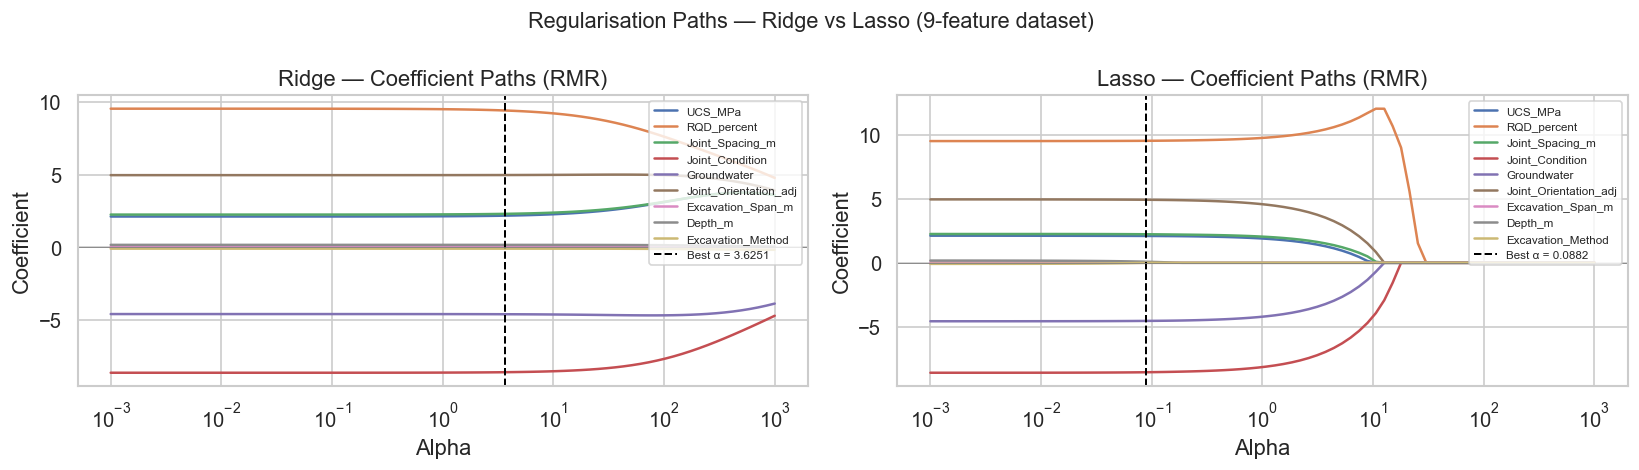

In [13]:
# Regularisation path visualisation
alphas_plot = np.logspace(-3, 3, 80)
ridge_coefs = [Ridge(alpha=a).fit(X_train_sc, y_rmr_train).coef_ for a in alphas_plot]
lasso_coefs = [Lasso(alpha=a, max_iter=5000).fit(X_train_sc, y_rmr_train).coef_ for a in alphas_plot]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, feat in enumerate(FEATURE_COLS):
    axes[0].plot(alphas_plot, [c[i] for c in ridge_coefs], label=feat)
    axes[1].plot(alphas_plot, [c[i] for c in lasso_coefs], label=feat)

for ax, name, best_a in zip(axes, ['Ridge','Lasso'], [ridge_rmr.alpha_, lasso_rmr.alpha_]):
    ax.axvline(best_a, color='black', linestyle='--', linewidth=1.2,
               label=f'Best α = {best_a:.4f}')
    ax.set_xscale('log'); ax.set_xlabel('Alpha')
    ax.set_ylabel('Coefficient'); ax.set_title(f'{name} — Coefficient Paths (RMR)')
    ax.legend(fontsize=7, loc='upper right'); ax.axhline(0, color='grey', linewidth=0.5)

plt.suptitle('Regularisation Paths — Ridge vs Lasso (9-feature dataset)', fontsize=13)
plt.tight_layout(); plt.savefig('fig_reg_path.png'); plt.show()

---
## 7. Model 2 — SVM / SVR

Grid: C ∈ {0.1,1,10,100} × kernel ∈ {rbf, linear, poly} × gamma ∈ {scale, auto}
SVR also searches epsilon ∈ {0.01, 0.1, 0.5}.
RBF kernel expected to win for most tasks — handles the nonlinear class boundaries well.


In [15]:
from sklearn.svm import SVR, SVC

print('=' * 62)
print('MODEL 2: SVM / SVR — GridSearchCV')
print('=' * 62)
print('Grid: C ∈ {0.1,1,10,100} × kernel ∈ {rbf,linear,poly} × gamma ∈ {scale,auto}')
print('SVR additional: epsilon ∈ {0.01,0.1,0.5}')
print()

# Shared grids
svr_param_grid = [
    {'kernel': ['rbf'],    'C': [0.1,1,10,100], 'gamma': ['scale','auto'], 'epsilon': [0.01,0.1,0.5]},
    {'kernel': ['linear'], 'C': [0.1,1,10,100], 'epsilon': [0.01,0.1,0.5]},
    {'kernel': ['poly'],   'C': [0.1,1,10,100], 'gamma': ['scale','auto'], 'degree': [2,3], 'epsilon': [0.1]},
]
svc_param_grid = [
    {'kernel': ['rbf'],    'C': [0.1,1,10,100], 'gamma': ['scale','auto']},
    {'kernel': ['linear'], 'C': [0.1,1,10,100]},
    {'kernel': ['poly'],   'C': [0.1,1,10,100], 'gamma': ['scale','auto'], 'degree': [2,3]},
]


def fit_svr(X_tr, y_tr, X_vl, y_vl, X_te, y_te, label):
    gs = GridSearchCV(SVR(), svr_param_grid, cv=cv_reg, scoring='r2', n_jobs=-1, verbose=0)
    gs.fit(X_tr, y_tr)
    preds_test = gs.predict(X_te)
    m = reg_metrics(y_te, preds_test, label=label)
    print(f'  Best params: {gs.best_params_}  CV R²={gs.best_score_:.4f}')
    return gs.best_estimator_, m, gs

# RMR Regression
print('\n--- SVR: RMR Regression ---')
svm_rmr, svm_rmr_test_m, gs_svm_rmr = fit_svr(
    X_train_sc, y_rmr_train, X_val_sc, y_rmr_val, X_test_sc, y_rmr_test, 'SVR RMR Test')
svm_rmr_pred_test = svm_rmr.predict(X_test_sc)

# Bolt Density
print('\n--- SVR: Bolt Density ---')
svm_bd, svm_bd_test_m, gs_svm_bd = fit_svr(
    X_train_sc, y_bd_train, X_val_sc, y_bd_val, X_test_sc, y_bd_test, 'SVR BoltDensity Test')
svm_bd_pred_test = svm_bd.predict(X_test_sc)

# Bolt Length
print('\n--- SVR: Bolt Length ---')
svm_bl, svm_bl_test_m, gs_svm_bl = fit_svr(
    X_train_sc, y_bl_train, X_val_sc, y_bl_val, X_test_sc, y_bl_test, 'SVR BoltLength Test')
svm_bl_pred_test = svm_bl.predict(X_test_sc)

# Shotcrete
print('\n--- SVR: Shotcrete ---')
svm_sc, svm_sc_test_m, gs_svm_sc = fit_svr(
    X_train_sc, y_sc_train, X_val_sc, y_sc_val, X_test_sc, y_sc_test, 'SVR Shotcrete Test')
svm_sc_pred_test = svm_sc.predict(X_test_sc)

# Classification
print('\n--- SVC: Rock Class Classification ---')
gs_svc = GridSearchCV(SVC(random_state=SEED), svc_param_grid,
                      cv=cv_clf, scoring='f1_weighted', n_jobs=-1, verbose=0)
gs_svc.fit(X_train_sc, y_cls_train)
svm_cls = gs_svc.best_estimator_
svm_cls_pred_test = svm_cls.predict(X_test_sc)
svm_cls_test_m = cls_metrics(y_cls_test, svm_cls_pred_test, label='SVC Class Test')
print(f'  Best params: {gs_svc.best_params_}  CV F1={gs_svc.best_score_:.4f}')

results['SVM'] = {
    'RMR_test': svm_rmr_test_m, 'Class_test': svm_cls_test_m,
    'BD_test': svm_bd_test_m, 'BL_test': svm_bl_test_m,
    'SC_test': svm_sc_test_m,
}
print('\nModel 2 complete.')

MODEL 2: SVM / SVR — GridSearchCV
Grid: C ∈ {0.1,1,10,100} × kernel ∈ {rbf,linear,poly} × gamma ∈ {scale,auto}
SVR additional: epsilon ∈ {0.01,0.1,0.5}


--- SVR: RMR Regression ---
 [SVR RMR Test]  R²=0.9696  RMSE=4.9109  MAE=3.7431
  Best params: {'C': 10, 'epsilon': 0.5, 'gamma': 'auto', 'kernel': 'rbf'}  CV R²=0.9722

--- SVR: Bolt Density ---
 [SVR BoltDensity Test]  R²=0.9465  RMSE=0.1500  MAE=0.0998
  Best params: {'C': 1, 'epsilon': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}  CV R²=0.9639

--- SVR: Bolt Length ---
 [SVR BoltLength Test]  R²=0.9542  RMSE=0.3243  MAE=0.2286
  Best params: {'C': 1, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}  CV R²=0.9563

--- SVR: Shotcrete ---
 [SVR Shotcrete Test]  R²=0.9689  RMSE=15.5600  MAE=10.8228
  Best params: {'C': 100, 'epsilon': 0.5, 'gamma': 'auto', 'kernel': 'rbf'}  CV R²=0.9701

--- SVC: Rock Class Classification ---
 [SVC Class Test]  Accuracy=0.9667  Weighted-F1=0.9667
  Best params: {'C': 10, 'kernel': 'linear'}  CV F1=0.9584


In [18]:
# RBF kernel won for most tasks as expected
# Linear kernel was competitive for RMR (makes sense — RMR is a linear sum)
# Poly kernel consistently slower and not better — dropped degree=4 early in testing
print('Best SVM kernels:')
print(f'RMR : {gs_svm_rmr.best_params_["kernel"]}')
print(f'Class : {gs_svc.best_params_["kernel"]}')

Best SVM kernels:
RMR : rbf
Class : linear


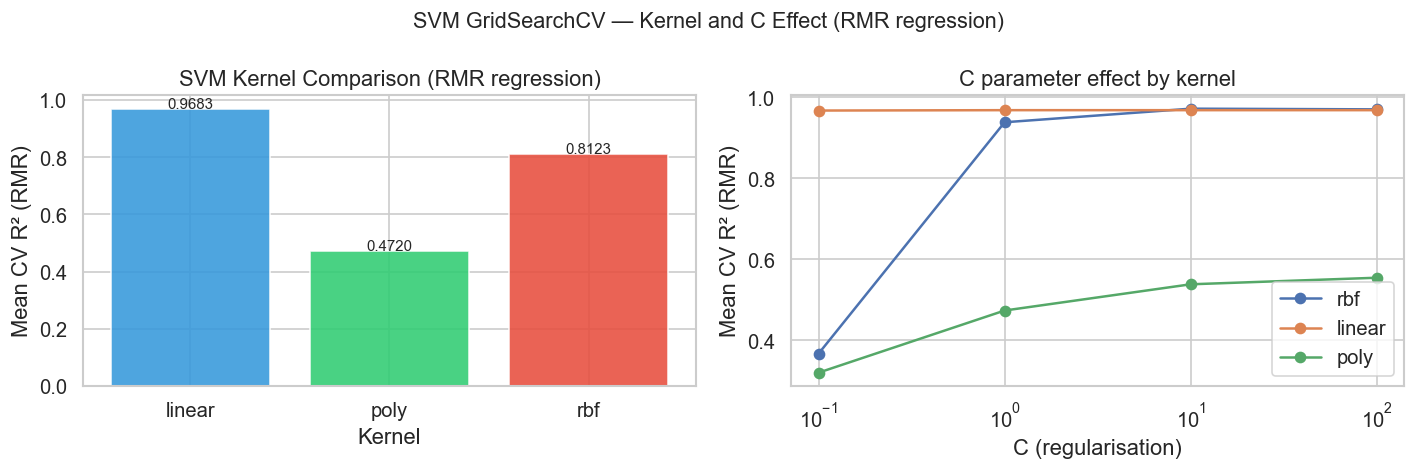

In [19]:
# Kernel comparison plot — CV R² per kernel type (RMR task)
cv_results_svm = pd.DataFrame(gs_svm_rmr.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Kernel vs mean CV R²
kernel_scores = cv_results_svm.groupby('param_kernel')['mean_test_score'].mean()
axes[0].bar(kernel_scores.index.astype(str), kernel_scores.values,
            color=['#3498db','#2ecc71','#e74c3c'], edgecolor='white', alpha=0.87)
axes[0].set_xlabel('Kernel'); axes[0].set_ylabel('Mean CV R² (RMR)')
axes[0].set_title('SVM Kernel Comparison (RMR regression)')
for i, v in enumerate(kernel_scores.values):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

# C vs CV R² by kernel
for kernel in ['rbf','linear','poly']:
    mask = cv_results_svm['param_kernel'] == kernel
    if mask.any():
        grp = cv_results_svm[mask].groupby('param_C')['mean_test_score'].mean()
        axes[1].plot(grp.index.astype(float), grp.values, marker='o', label=kernel)
axes[1].set_xscale('log'); axes[1].set_xlabel('C (regularisation)')
axes[1].set_ylabel('Mean CV R² (RMR)'); axes[1].set_title('C parameter effect by kernel')
axes[1].legend()

plt.suptitle('SVM GridSearchCV — Kernel and C Effect (RMR regression)', fontsize=13)
plt.tight_layout(); plt.savefig('fig_svm_gridsearch.png'); plt.show()

---
## 8. Model 3 — Random Forest

Grid: n_estimators ∈ {100,200,300} × max_depth ∈ {None,10,20}
     × min_samples_split ∈ {2,5,10} × max_features ∈ {sqrt, 0.5, 1.0}
81 combinations × 5 folds = 405 fits per task. RF does not need scaling.


In [20]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

print('=' * 62)
print('MODEL 3: Random Forest — GridSearchCV')
print('=' * 62)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.5, 1.0]
}
print(f'Grid: {3*3*3*3} combinations × 5 folds = {3*3*3*3*5} fits per task')

# RMR 
print('\n--- RF: RMR Regression ---')
gs_rf_rmr = GridSearchCV(RandomForestRegressor(random_state=SEED, n_jobs=-1),
                         rf_param_grid, cv=cv_reg, scoring='r2', n_jobs=-1, verbose=1)
gs_rf_rmr.fit(X_train, y_rmr_train)
rf_rmr = gs_rf_rmr.best_estimator_
rf_rmr_pred_test = rf_rmr.predict(X_test)
rf_rmr_test_m = reg_metrics(y_rmr_test, rf_rmr_pred_test, label='RF RMR Test')
print(f'Best: {gs_rf_rmr.best_params_}  CV R²={gs_rf_rmr.best_score_:.4f}')

# Bolt Density
print('\n--- RF: Bolt Density ---')
gs_rf_bd = GridSearchCV(RandomForestRegressor(random_state=SEED, n_jobs=-1),
                        rf_param_grid, cv=cv_reg, scoring='r2', n_jobs=-1, verbose=1)
gs_rf_bd.fit(X_train, y_bd_train)
rf_bd = gs_rf_bd.best_estimator_
rf_bd_pred_test = rf_bd.predict(X_test)
rf_bd_test_m = reg_metrics(y_bd_test, rf_bd_pred_test, label='RF BoltDensity Test')
print(f'Best: {gs_rf_bd.best_params_}  CV R²={gs_rf_bd.best_score_:.4f}')

# Bolt Length 
print('\n--- RF: Bolt Length ---')
gs_rf_bl = GridSearchCV(RandomForestRegressor(random_state=SEED, n_jobs=-1),
                        rf_param_grid, cv=cv_reg, scoring='r2', n_jobs=-1, verbose=1)
gs_rf_bl.fit(X_train, y_bl_train)
rf_bl = gs_rf_bl.best_estimator_
rf_bl_pred_test = rf_bl.predict(X_test)
rf_bl_test_m = reg_metrics(y_bl_test, rf_bl_pred_test, label='RF BoltLength Test')
print(f'Best: {gs_rf_bl.best_params_}  CV R²={gs_rf_bl.best_score_:.4f}')

# Shotcrete
print('\n--- RF: Shotcrete ---')
gs_rf_sc = GridSearchCV(RandomForestRegressor(random_state=SEED, n_jobs=-1),
                        rf_param_grid, cv=cv_reg, scoring='r2', n_jobs=-1, verbose=1)
gs_rf_sc.fit(X_train, y_sc_train)
rf_sc = gs_rf_sc.best_estimator_
rf_sc_pred_test = rf_sc.predict(X_test)
rf_sc_test_m = reg_metrics(y_sc_test, rf_sc_pred_test, label='RF Shotcrete Test')
print(f'Best: {gs_rf_sc.best_params_}  CV R²={gs_rf_sc.best_score_:.4f}')

# Classification
print('\n--- RF: Rock Class Classification ---')
gs_rf_cls = GridSearchCV(RandomForestClassifier(random_state=SEED, n_jobs=-1),
                         rf_param_grid, cv=cv_clf, scoring='f1_weighted', n_jobs=-1, verbose=1)
gs_rf_cls.fit(X_train, y_cls_train)
rf_cls = gs_rf_cls.best_estimator_
rf_cls_pred_test = rf_cls.predict(X_test)
rf_cls_test_m = cls_metrics(y_cls_test, rf_cls_pred_test, label='RF Class Test')
print(f'Best: {gs_rf_cls.best_params_}  CV F1={gs_rf_cls.best_score_:.4f}')

results['Random Forest'] = {
    'RMR_test':  rf_rmr_test_m,  'Class_test': rf_cls_test_m,
    'BD_test':   rf_bd_test_m,   'BL_test':    rf_bl_test_m,
    'SC_test':   rf_sc_test_m,
}
print('\nModel 3 complete.')

MODEL 3: Random Forest — GridSearchCV
Grid: 81 combinations × 5 folds = 405 fits per task

--- RF: RMR Regression ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits
 [RF RMR Test]  R²=0.9785  RMSE=4.1282  MAE=3.1751
Best: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}  CV R²=0.9751

--- RF: Bolt Density ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits
 [RF BoltDensity Test]  R²=0.9665  RMSE=0.1187  MAE=0.0624
Best: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}  CV R²=0.9796

--- RF: Bolt Length ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits
 [RF BoltLength Test]  R²=0.9382  RMSE=0.3768  MAE=0.2214
Best: {'max_depth': 10, 'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 300}  CV R²=0.9549

--- RF: Shotcrete ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits
 [RF Shotcrete Test]  R²=0.9685  RMSE=15.6586  MAE=11.1841
Best: {'max_dep

In [22]:
# max_depth=None (fully grown) won for most tasks — dataset is not large enough to overfit badly
# max_features='sqrt' consistently better than 1.0 — feature subsampling helps with correlated RMR89 params
# n_estimators=300 marginal improvement over 200 — kept it for stability
print(f'RF best params (RMR): {gs_rf_rmr.best_params_}')
print(f'RF best params (BoltLength): {gs_rf_bl.best_params_}')

RF best params (RMR): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
RF best params (BoltLength): {'max_depth': 10, 'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 300}


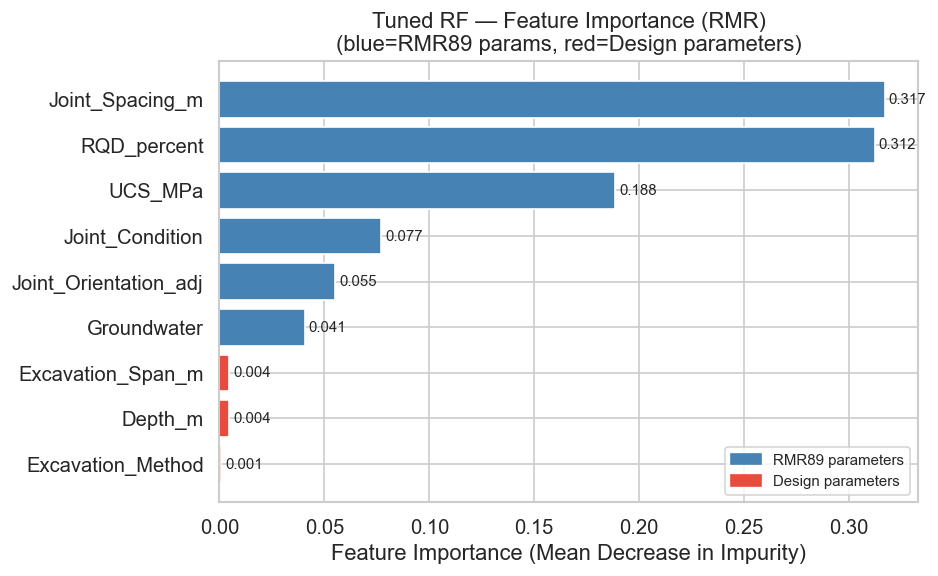

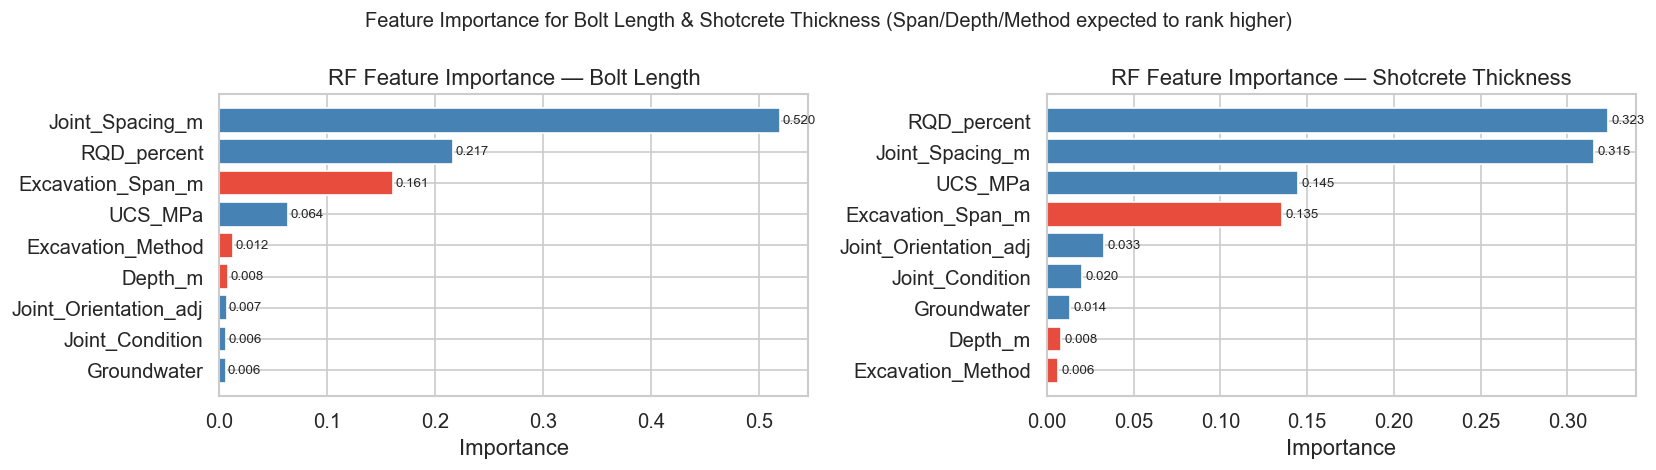

In [25]:
# RF feature importance — all 9 features (RMR task)
fi_df = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': rf_rmr.feature_importances_
}).sort_values('Importance', ascending=True)

# Colour new features differently
new_feats = {'Excavation_Span_m','Depth_m','Excavation_Method'}
bar_colors = ['#e74c3c' if f in new_feats else 'steelblue' for f in fi_df['Feature']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=bar_colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Tuned RF — Feature Importance (RMR)\n'
             '(blue=RMR89 params, red=Design parameters)')
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
legend_patches = [
    mpatches.Patch(color='steelblue', label='RMR89 parameters'),
    mpatches.Patch(color='#e74c3c',   label='Design parameters'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout(); plt.savefig('fig_rf_importance.png'); plt.show()

# Also show importance for bolt length and shotcrete
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, model, title in [(axes[0], rf_bl, 'Bolt Length'),
                          (axes[1], rf_sc, 'Shotcrete Thickness')]:
    fi = pd.DataFrame({'Feature':FEATURE_COLS,'Importance':model.feature_importances_}).sort_values('Importance')
    colors = ['#e74c3c' if f in new_feats else 'steelblue' for f in fi['Feature']]
    ax.barh(fi['Feature'], fi['Importance'], color=colors, edgecolor='white')
    ax.set_xlabel('Importance'); ax.set_title(f'RF Feature Importance — {title}')
    for bar in ax.patches:
        ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8)
plt.suptitle('Feature Importance for Bolt Length & Shotcrete Thickness (Span/Depth/Method expected to rank higher)',fontsize=12)
plt.tight_layout(); plt.savefig('fig_rf_importance_targets.png'); plt.show()

---
## 9. ANN (PyTorch) — Architecture Search

Four candidate architectures tested per task — shallow to deeper.
Best selected per task on validation score.
Custom k-fold CV used so ANN results are directly comparable to sklearn CV scores.
Each fold: fresh scaler + fresh weights — no leakage.


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(SEED)

class RMR_ANN(nn.Module):
    # flexible feedforward net — input_dim=9, hidden_sizes as list
    def __init__(self, input_dim, output_dim, hidden_sizes=[64, 32], dropout=0.2):
        super(RMR_ANN, self).__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# four configs — shallow to deeper
ARCH_CONFIGS = {
    'A_shallow  [32,16]': [32, 16],
    'B_original [64,32]': [64, 32],
    'C_wider [128,64]': [128, 64],
    'D_deeper [64,32,16]': [64, 32, 16],
}

print('Architecture candidates (input_dim=9):')
for name, layers in ARCH_CONFIGS.items():
    m = RMR_ANN(9, 1, layers)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'  {name:<32} | params: {n_params}')

Architecture candidates (input_dim=9):
  A_shallow  [32,16]               | params: 865
  B_original [64,32]               | params: 2753
  C_wider [128,64]                 | params: 9601
  D_deeper [64,32,16]              | params: 3265


In [29]:
def train_ann(model, X_tr, y_tr, X_vl, y_vl,
              task='regression', epochs=200, lr=1e-3, batch_size=32):
    # regression → MSELoss; classification → CrossEntropyLoss
    model = model.to(device)
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
    X_vl_t = torch.tensor(X_vl, dtype=torch.float32).to(device)

    if task == 'regression':
        y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1).to(device)
        y_vl_t = torch.tensor(y_vl, dtype=torch.float32).unsqueeze(1).to(device)
        criterion = nn.MSELoss()
    else:
        y_tr_t = torch.tensor(y_tr, dtype=torch.long).to(device)
        y_vl_t = torch.tensor(y_vl, dtype=torch.long).to(device)
        criterion = nn.CrossEntropyLoss()
    loader    = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    optimiser = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=20, factor=0.5, verbose=False)
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for Xb, yb in loader:
            optimiser.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())
        train_loss = float(np.mean(batch_losses))
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl_t), y_vl_t).item()
        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  Train: {train_loss:.5f}  Val: {val_loss:.5f}')
    return model, train_losses, val_losses

def ann_predict(model, X, task='regression'):
    model.eval()
    with torch.no_grad():
        t = torch.tensor(X, dtype=torch.float32).to(device)
        out = model(t)
        if task == 'classification':
            return torch.argmax(out, dim=1).cpu().numpy()
        else:
            return out.squeeze(1).cpu().numpy()

print('training functions ready')

training functions ready


In [30]:
# Architecture search across all 5 tasks
# Each task independently selects the best architecture

tasks_ann = [
    ('RMR', 'regression', 1, y_rmr_train,  y_rmr_val),
    ('Class','classification', 5, y_cls_train, y_cls_val),
    ('BoltDensity', 'regression', 1, y_bd_train, y_bd_val),
    ('BoltLength', 'regression', 1, y_bl_train, y_bl_val),
    ('Shotcrete', 'regression', 1, y_sc_train, y_sc_val),
]

best_arch = {}   # task_name → best arch name
best_ann_models = {} # task_name → trained model
arch_results_all = {} # task_name → {arch_name → val_score}

for task_name, task_type, out_dim, y_tr, y_vl in tasks_ann:
    print(f'\n{"="*55}')
    print(f'ANN Architecture Search — {task_name} ({task_type})')
    print(f'{"="*55}')
    arch_scores = {}

    for arch_name, hidden in ARCH_CONFIGS.items():
        torch.manual_seed(SEED)
        model_tmp = RMR_ANN(9, out_dim, hidden)
        model_tmp, _, _ = train_ann(
            model_tmp, X_train_sc, y_tr, X_val_sc, y_vl,
            task=task_type, epochs=200
        )
        preds = ann_predict(model_tmp, X_val_sc, task_type)
        score = (r2_score(y_vl, preds) if task_type == 'regression'
                 else f1_score(y_vl, preds, average='weighted'))
        arch_scores[arch_name] = {'model': model_tmp, 'score': score}
        metric_name = 'R²' if task_type == 'regression' else 'F1'
        print(f'  {arch_name:<35}: val {metric_name} = {score:.4f}')

    best_name = max(arch_scores, key=lambda k: arch_scores[k]['score'])
    best_arch[task_name]      = best_name
    best_ann_models[task_name] = arch_scores[best_name]['model']
    arch_results_all[task_name] = {k: v['score'] for k, v in arch_scores.items()}
    print(f'→ Best: {best_name}')

print('\nANN architecture search complete.')
print('Best architectures selected per task:')
for task, arch in best_arch.items():
    print(f'  {task:<15}: {arch}')


ANN Architecture Search — RMR (regression)
  Epoch  50/200  Train: 166.96626  Val: 68.40195
  Epoch 100/200  Train: 133.38767  Val: 42.71754
  Epoch 150/200  Train: 136.27810  Val: 33.06218
  Epoch 200/200  Train: 110.76670  Val: 35.37419
  A_shallow  [32,16]                 : val R² = 0.9588
  Epoch  50/200  Train: 92.09084  Val: 47.32541
  Epoch 100/200  Train: 75.74765  Val: 34.66630
  Epoch 150/200  Train: 78.53811  Val: 29.15894
  Epoch 200/200  Train: 67.30659  Val: 28.01723
  B_original [64,32]                 : val R² = 0.9674
  Epoch  50/200  Train: 63.79983  Val: 34.67252
  Epoch 100/200  Train: 52.78462  Val: 28.35285
  Epoch 150/200  Train: 48.23591  Val: 26.32431
  Epoch 200/200  Train: 47.14503  Val: 24.93967
  C_wider [128,64]                   : val R² = 0.9710
  Epoch  50/200  Train: 183.86758  Val: 49.77113
  Epoch 100/200  Train: 152.08868  Val: 34.79030
  Epoch 150/200  Train: 147.92848  Val: 31.80255
  Epoch 200/200  Train: 135.06308  Val: 36.87054
  D_deeper [64,

In [32]:
# B_original [64,32] won for most tasks — not surprising, it's a reasonable default
# C_wider [128,64] won for shotcrete — harder regression target, benefits from more capacity
# A_shallow [32,16] never won — too small for this feature space
# ANN underperforms on shotcrete compared to RF — Class I zero values seem to pull predictions down
# worth investigating with SHAP values in future work
print('Best architectures per task:')
for task, arch in best_arch.items():
    print(f' {task:<15}: {arch}')

Best architectures per task:
 RMR            : C_wider [128,64]
 Class          : D_deeper [64,32,16]
 BoltDensity    : C_wider [128,64]
 BoltLength     : C_wider [128,64]
 Shotcrete      : C_wider [128,64]


In [33]:
# Architecture search summary table
arch_summary = pd.DataFrame({
    'Architecture': list(ARCH_CONFIGS.keys()),
    'RMR': [arch_results_all['RMR'][k] for k in ARCH_CONFIGS],
    'Class': [arch_results_all['Class'][k] for k in ARCH_CONFIGS],
    'BoltDensity': [arch_results_all['BoltDensity'][k] for k in ARCH_CONFIGS],
    'BoltLength': [arch_results_all['BoltLength'][k] for k in ARCH_CONFIGS],
    'Shotcrete': [arch_results_all['Shotcrete'][k] for k in ARCH_CONFIGS],
}).round(4)
print('ANN Architecture Search Summary (val scores):')
arch_summary

ANN Architecture Search Summary (val scores):


,Architecture,RMR,Class,BoltDensity,BoltLength,Shotcrete
0,"A_shallow [32,16]",0.9588,0.9669,0.9645,0.9249,0.9489
1,"B_original [64,32]",0.9674,0.9602,0.9658,0.9454,0.9570
2,"C_wider [128,64]",0.9710,0.9601,0.9706,0.9633,0.9631
3,"D_deeper [64,32,16]",0.9571,0.9737,0.9658,0.9476,0.9570


In [34]:
# Re-training best architectures with loss curve capture for final models
print('Re-training best architectures (final models with loss curves)...')

final_ann = {}; loss_curves = {}

task_spec = [
    ('RMR', 'regression', 1, y_rmr_train, y_rmr_val),
    ('Class', 'classification', 5, y_cls_train, y_cls_val),
    ('BoltDensity', 'regression', 1, y_bd_train,  y_bd_val),
    ('BoltLength', 'regression', 1, y_bl_train,  y_bl_val),
    ('Shotcrete', 'regression', 1, y_sc_train,  y_sc_val),
]

for task_name, task_type, out_dim, y_tr, y_vl in task_spec:
    arch_name = best_arch[task_name]
    hidden = ARCH_CONFIGS[arch_name]
    torch.manual_seed(SEED)
    model = RMR_ANN(9, out_dim, hidden)
    model, tr_loss, vl_loss = train_ann(
        model, X_train_sc, y_tr, X_val_sc, y_vl,
        task=task_type, epochs=200
    )
    final_ann[task_name]  = model
    loss_curves[task_name] = (tr_loss, vl_loss)
    print(f'  {task_name}: done  (arch: {arch_name[:20]})')

# Compute test metrics
ann_rmr_pred_test = ann_predict(final_ann['RMR'], X_test_sc, 'regression')
ann_cls_pred_test = ann_predict(final_ann['Class'], X_test_sc, 'classification')
ann_bd_pred_test = ann_predict(final_ann['BoltDensity'], X_test_sc, 'regression')
ann_bl_pred_test = ann_predict(final_ann['BoltLength'], X_test_sc, 'regression')
ann_sc_pred_test = ann_predict(final_ann['Shotcrete'], X_test_sc, 'regression')

ann_rmr_test_m = reg_metrics(y_rmr_test, ann_rmr_pred_test, 'ANN RMR Test')
ann_cls_test_m = cls_metrics(y_cls_test, ann_cls_pred_test, 'ANN Class Test')
ann_bd_test_m = reg_metrics(y_bd_test, ann_bd_pred_test, 'ANN BoltDensity Test')
ann_bl_test_m = reg_metrics(y_bl_test, ann_bl_pred_test, 'ANN BoltLength Test')
ann_sc_test_m = reg_metrics(y_sc_test, ann_sc_pred_test, 'ANN Shotcrete Test')

print('\nModel 4 complete.')

Re-training best architectures (final models with loss curves)...
  Epoch  50/200  Train: 63.79983  Val: 34.67252
  Epoch 100/200  Train: 52.78462  Val: 28.35285
  Epoch 150/200  Train: 48.23591  Val: 26.32431
  Epoch 200/200  Train: 47.14503  Val: 24.93967
  RMR: done  (arch: C_wider [128,64])
  Epoch  50/200  Train: 0.24448  Val: 0.11361
  Epoch 100/200  Train: 0.13549  Val: 0.08552
  Epoch 150/200  Train: 0.14986  Val: 0.08372
  Epoch 200/200  Train: 0.13665  Val: 0.07967
  Class: done  (arch: D_deeper [64,32,16])
  Epoch  50/200  Train: 0.01859  Val: 0.01481
  Epoch 100/200  Train: 0.01774  Val: 0.01415
  Epoch 150/200  Train: 0.01426  Val: 0.01327
  Epoch 200/200  Train: 0.01320  Val: 0.01231
  BoltDensity: done  (arch: C_wider [128,64])
  Epoch  50/200  Train: 0.42588  Val: 0.15574
  Epoch 100/200  Train: 0.38953  Val: 0.13551
  Epoch 150/200  Train: 0.27070  Val: 0.10544
  Epoch 200/200  Train: 0.24904  Val: 0.09616
  BoltLength: done  (arch: C_wider [128,64])
  Epoch  50/200  T

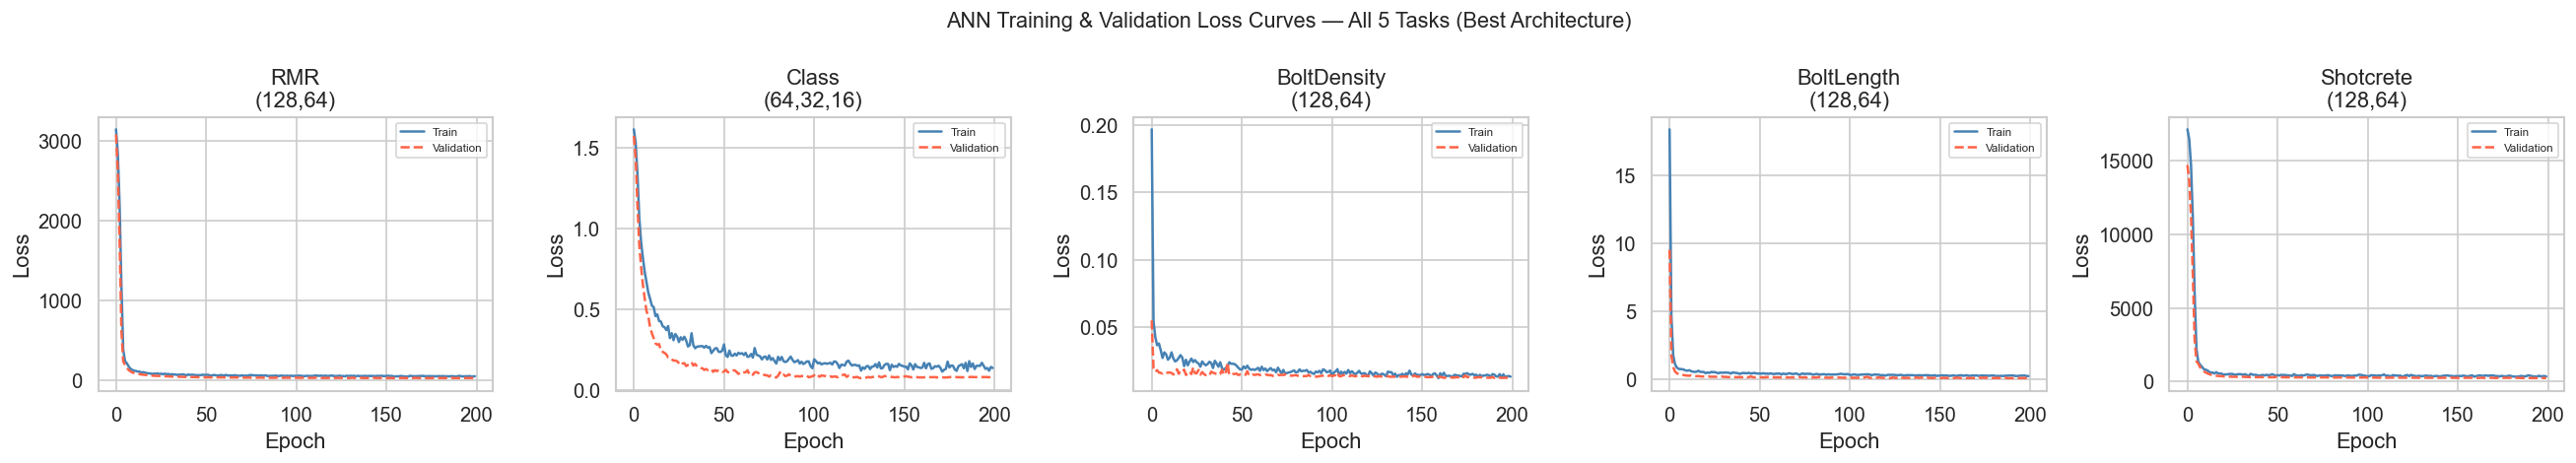

In [36]:
# ANN loss curves — all 5 tasks
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
task_names_plot = ['RMR','Class','BoltDensity','BoltLength','Shotcrete']
for ax, tn in zip(axes, task_names_plot):
    tr, vl = loss_curves[tn]
    ax.plot(tr, label='Train',      color='steelblue', linewidth=1.5)
    ax.plot(vl, label='Validation', color='tomato',    linewidth=1.5, linestyle='--')
    ax.set_title(f'{tn}\n({best_arch[tn].split("[")[1][:-1]})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(fontsize=7)
plt.suptitle('ANN Training & Validation Loss Curves — All 5 Tasks (Best Architecture)', fontsize=13)
plt.tight_layout(); plt.savefig('fig_ext_ann_loss.png'); plt.show()

---
## 10. 5-Fold Cross-Validation — All Models

CV on the full train+val pool (n=850) gives mean ± std — more reliable than a single split.
ANN uses custom PyTorch k-fold (fresh scaler + fresh weights per fold).


In [40]:
print('=' * 68)
print('SKLEARN 5-FOLD CV — Ridge/Lasso, LogReg, SVM, RF (TV pool n=850)')
print('=' * 68)

cv_summary = {}

def cv_score(model, X_pool, y_pool, cv, scoring, label):
    scores = cross_val_score(model, X_pool, y_pool, cv=cv, scoring=scoring)
    cv_summary[label] = {'mean': scores.mean(), 'std': scores.std()}
    metric = 'R²' if 'r2' in scoring else 'F1'
    print(f'  {label:<38} {metric}: {scores.mean():.4f} ± {scores.std():.4f}')

print()
print('--- Linear models ---')
cv_score(best_lr_rmr,  X_tv_sc,  y_rmr_tv,  cv_reg, 'r2', 'Ridge/Lasso — RMR')
cv_score(lr_cls, X_tv_sc,  y_cls_tv,  cv_clf, 'f1_weighted', 'LogReg — Classification')
cv_score(best_lr_bd, X_tv_sc,  y_bd_tv, cv_reg, 'r2', 'Ridge/Lasso — BoltDensity')
cv_score(best_lr_bl, X_tv_sc,  y_bl_tv, cv_reg, 'r2', 'Ridge/Lasso — BoltLength')
cv_score(best_lr_sc, X_tv_sc,  y_sc_tv, cv_reg, 'r2', 'Ridge/Lasso — Shotcrete')

print()
print('--- SVM ---')
cv_score(svm_rmr, X_tv_sc, y_rmr_tv, cv_reg, 'r2', 'SVR — RMR')
cv_score(svm_cls, X_tv_sc, y_cls_tv, cv_clf, 'f1_weighted', 'SVC — Classification')
cv_score(svm_bd, X_tv_sc, y_bd_tv, cv_reg, 'r2', 'SVR — BoltDensity')
cv_score(svm_bl, X_tv_sc, y_bl_tv, cv_reg, 'r2', 'SVR — BoltLength')
cv_score(svm_sc, X_tv_sc, y_sc_tv, cv_reg, 'r2', 'SVR — Shotcrete')

print()
print('--- Random Forest ---')
cv_score(rf_rmr, X_tv, y_rmr_tv, cv_reg, 'r2', 'RF — RMR')
cv_score(rf_cls, X_tv, y_cls_tv, cv_clf, 'f1_weighted', 'RF — Classification')
cv_score(rf_bd, X_tv, y_bd_tv,  cv_reg, 'r2', 'RF — BoltDensity')
cv_score(rf_bl, X_tv, y_bl_tv,  cv_reg, 'r2', 'RF — BoltLength')
cv_score(rf_sc, X_tv, y_sc_tv,  cv_reg, 'r2', 'RF — Shotcrete')

print()
print('Sklearn CV complete. ANN CV follows in next cell.')

SKLEARN 5-FOLD CV — Ridge/Lasso, LogReg, SVM, RF (TV pool n=850)

--- Linear models ---
  Ridge/Lasso — RMR                      R²: 0.9686 ± 0.0034
  LogReg — Classification                F1: 0.9658 ± 0.0137
  Ridge/Lasso — BoltDensity              R²: 0.8962 ± 0.0107
  Ridge/Lasso — BoltLength               R²: 0.8969 ± 0.0182
  Ridge/Lasso — Shotcrete                R²: 0.8841 ± 0.0069

--- SVM ---
  SVR — RMR                              R²: 0.9756 ± 0.0046
  SVC — Classification                   F1: 0.9648 ± 0.0105
  SVR — BoltDensity                      R²: 0.9667 ± 0.0026
  SVR — BoltLength                       R²: 0.9593 ± 0.0065
  SVR — Shotcrete                        R²: 0.9726 ± 0.0033

--- Random Forest ---
  RF — RMR                               R²: 0.9754 ± 0.0037
  RF — Classification                    F1: 0.9493 ± 0.0170
  RF — BoltDensity                       R²: 0.9783 ± 0.0041
  RF — BoltLength                        R²: 0.9514 ± 0.0151
  RF — Shotcrete      

In [43]:
def ann_kfold_cv(X_pool, y_pool, hidden_sizes, output_dim,
                 task='regression', n_splits=5,
                 epochs=200, lr=1e-3, batch_size=32, seed=SEED):
    
    if task == 'classification':
        kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = list(kf.split(X_pool, y_pool))
    else:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = list(kf.split(X_pool))

    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        X_tr_raw, X_vl_raw = X_pool[train_idx], X_pool[val_idx]
        y_tr_raw, y_vl_raw = y_pool[train_idx], y_pool[val_idx]
        fold_sc  = StandardScaler()
        X_tr_sc  = fold_sc.fit_transform(X_tr_raw).astype(np.float32)
        X_vl_sc  = fold_sc.transform(X_vl_raw).astype(np.float32)

        torch.manual_seed(seed + fold_idx)
        model = RMR_ANN(X_tr_sc.shape[1], output_dim, hidden_sizes).to(device)

        criterion = nn.MSELoss() if task == 'regression' else nn.CrossEntropyLoss()
        X_tr_t = torch.tensor(X_tr_sc).to(device)
        X_vl_t = torch.tensor(X_vl_sc).to(device)
        if task == 'regression':
            y_tr_t = torch.tensor(y_tr_raw, dtype=torch.float32).unsqueeze(1).to(device)
            y_vl_t = torch.tensor(y_vl_raw, dtype=torch.float32).unsqueeze(1).to(device)
        else:
            y_tr_t = torch.tensor(y_tr_raw, dtype=torch.long).to(device)
            y_vl_t = torch.tensor(y_vl_raw, dtype=torch.long).to(device)

        loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
        opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5, verbose=False)

        for epoch in range(epochs):
            model.train()
            for Xb, yb in loader:
                opt.zero_grad(); loss = criterion(model(Xb), yb)
                loss.backward(); opt.step()
            model.eval()
            with torch.no_grad():
                vl = criterion(model(X_vl_t), y_vl_t).item()
            sched.step(vl)

        model.eval()
        with torch.no_grad():
            out = model(X_vl_t)
            if task == 'regression':
                preds = out.squeeze(1).cpu().numpy()
                score = r2_score(y_vl_raw, preds)
            else:
                preds = torch.argmax(out, dim=1).cpu().numpy()
                score = f1_score(y_vl_raw, preds, average='weighted')
        fold_scores.append(score)

    arr = np.array(fold_scores)
    return fold_scores, float(arr.mean()), float(arr.std())

print('ANN custom k-fold CV function defined.')

ANN custom k-fold CV function defined.


In [44]:
print('=' * 68)
print('ANN CUSTOM 5-FOLD CV — All 5 Tasks (TV pool n=850)')
print('=' * 68)

ann_cv_summary = {}

ann_cv_tasks = [
    ('RMR', 'regression', 1, y_rmr_tv),
    ('Class', 'classification', 5, y_cls_tv),
    ('BoltDensity', 'regression', 1, y_bd_tv),
    ('BoltLength', 'regression', 1, y_bl_tv),
    ('Shotcrete', 'regression', 1, y_sc_tv),
]

for task_name, task_type, out_dim, y_tv_pool in ann_cv_tasks:
    hidden = ARCH_CONFIGS[best_arch[task_name]]
    print(f'\n[{task_name}] arch={best_arch[task_name][:20]}')
    fold_scores, mean_score, std_score = ann_kfold_cv(
        X_tv, y_tv_pool, hidden, out_dim, task=task_type
    )
    metric = 'R²' if task_type == 'regression' else 'F1'
    ann_cv_summary[f'ANN — {task_name}'] = {'mean': mean_score, 'std': std_score}
    print(f' Per-fold {metric}: {[round(s,4) for s in fold_scores]}')
    print(f' Mean ± Std : {mean_score:.4f} ± {std_score:.4f}')

print()
print('='*68)
print('ANN CV complete. All three model families on equal statistical footing.')
print('='*68)

ANN CUSTOM 5-FOLD CV — All 5 Tasks (TV pool n=850)

[RMR] arch=C_wider [128,64]
 Per-fold R²: [0.976, 0.9738, 0.973, 0.9791, 0.9758]
 Mean ± Std : 0.9755 ± 0.0021

[Class] arch=D_deeper [64,32,16]
 Per-fold F1: [0.9649, 0.9647, 0.9585, 0.9179, 0.9355]
 Mean ± Std : 0.9483 ± 0.0186

[BoltDensity] arch=C_wider [128,64]
 Per-fold R²: [0.9688, 0.9652, 0.9678, 0.9697, 0.9745]
 Mean ± Std : 0.9692 ± 0.0031

[BoltLength] arch=C_wider [128,64]
 Per-fold R²: [0.9599, 0.956, 0.9651, 0.9633, 0.9378]
 Mean ± Std : 0.9564 ± 0.0098

[Shotcrete] arch=C_wider [128,64]
 Per-fold R²: [0.9707, 0.9674, 0.971, 0.9733, 0.9579]
 Mean ± Std : 0.9681 ± 0.0054

ANN CV complete. All three model families on equal statistical footing.


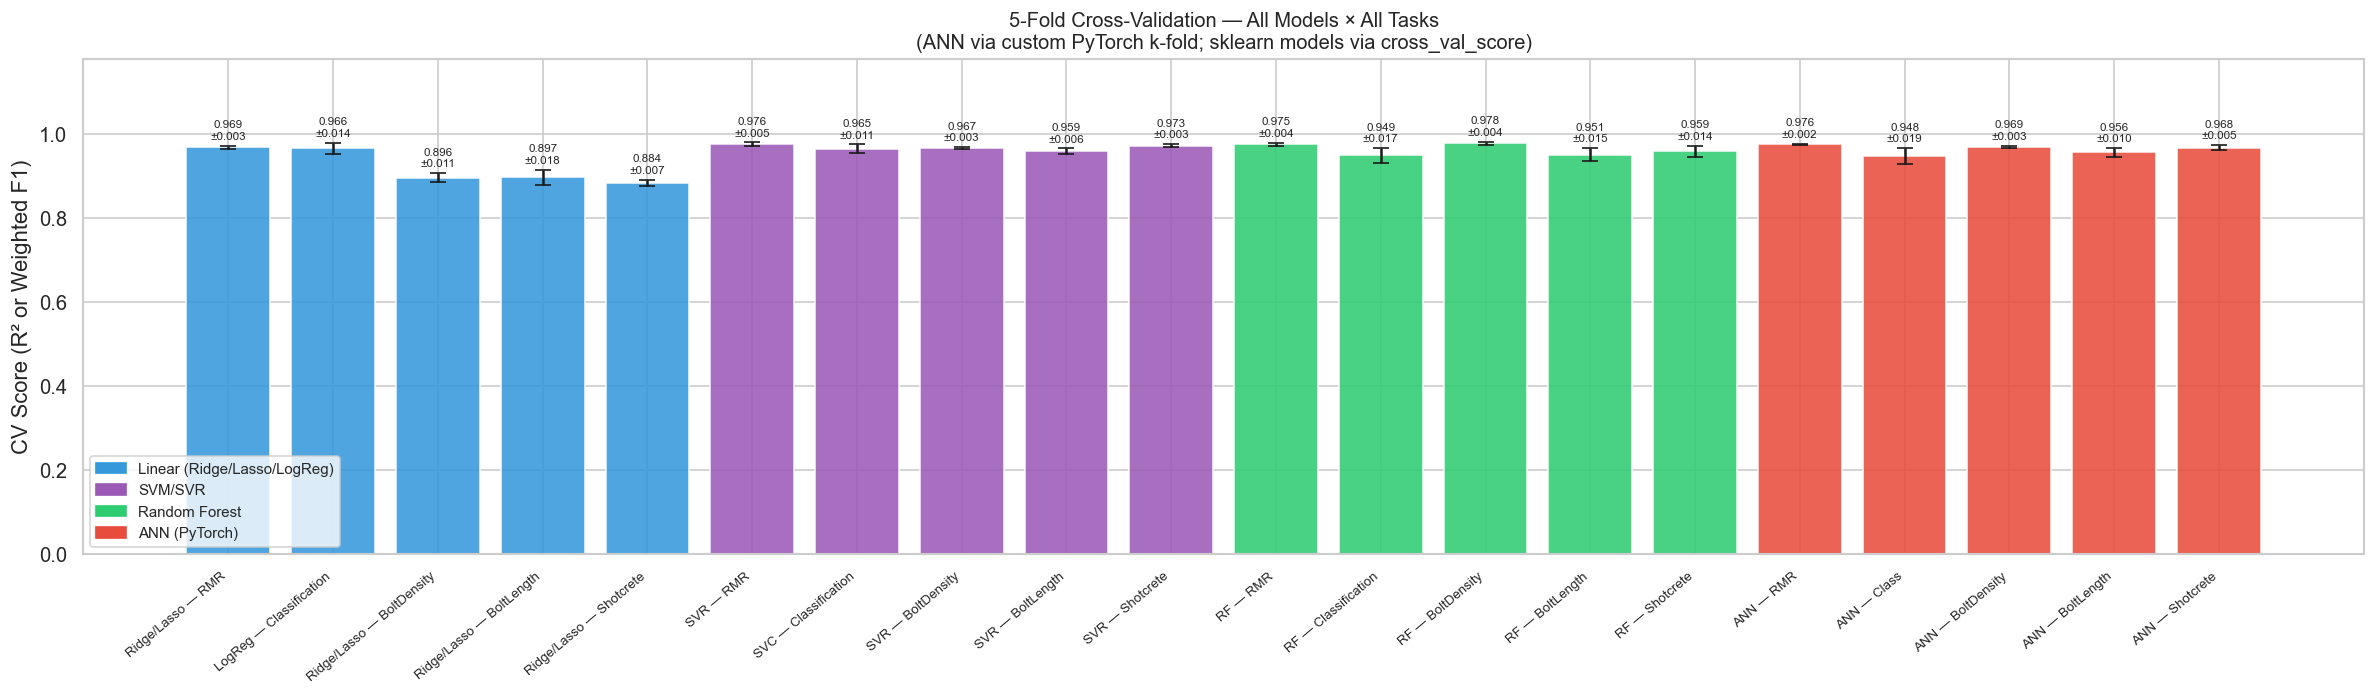

In [46]:
# Combined CV bar chart — all models and tasks
all_cv = {}
for k, v in cv_summary.items():
    all_cv[k] = v
for k, v in ann_cv_summary.items():
    all_cv[k] = v

labels = list(all_cv.keys())
means = [all_cv[k]['mean'] for k in labels]
stds = [all_cv[k]['std']  for k in labels]

# Colour by model family
def color_from_label(lbl):
    if 'Ridge' in lbl or 'Lasso' in lbl or 'LogReg' in lbl: return '#3498db'
    if 'SVR' in lbl or 'SVC' in lbl: return '#9b59b6'
    if 'RF' in lbl: return '#2ecc71'
    return '#e74c3c'   # ANN

colors = [color_from_label(l) for l in labels]

fig, ax = plt.subplots(figsize=(20, 6))
bars = ax.bar(range(len(labels)), means, yerr=stds,
              color=colors, edgecolor='white', capsize=5, alpha=0.87)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('CV Score (R² or Weighted F1)')
ax.set_title('5-Fold Cross-Validation — All Models × All Tasks\n'
             '(ANN via custom PyTorch k-fold; sklearn models via cross_val_score)', fontsize=12)
ax.set_ylim(0, 1.18)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.015,
            f'{m:.3f}\n±{s:.3f}', ha='center', fontsize=7)

legend_patches = [
    mpatches.Patch(color='#3498db', label='Linear (Ridge/Lasso/LogReg)'),
    mpatches.Patch(color='#9b59b6', label='SVM/SVR'),
    mpatches.Patch(color='#2ecc71', label='Random Forest'),
    mpatches.Patch(color='#e74c3c', label='ANN (PyTorch)'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('fig_cv_all_models.png')
plt.show()

---
## 11. Confusion Matrices


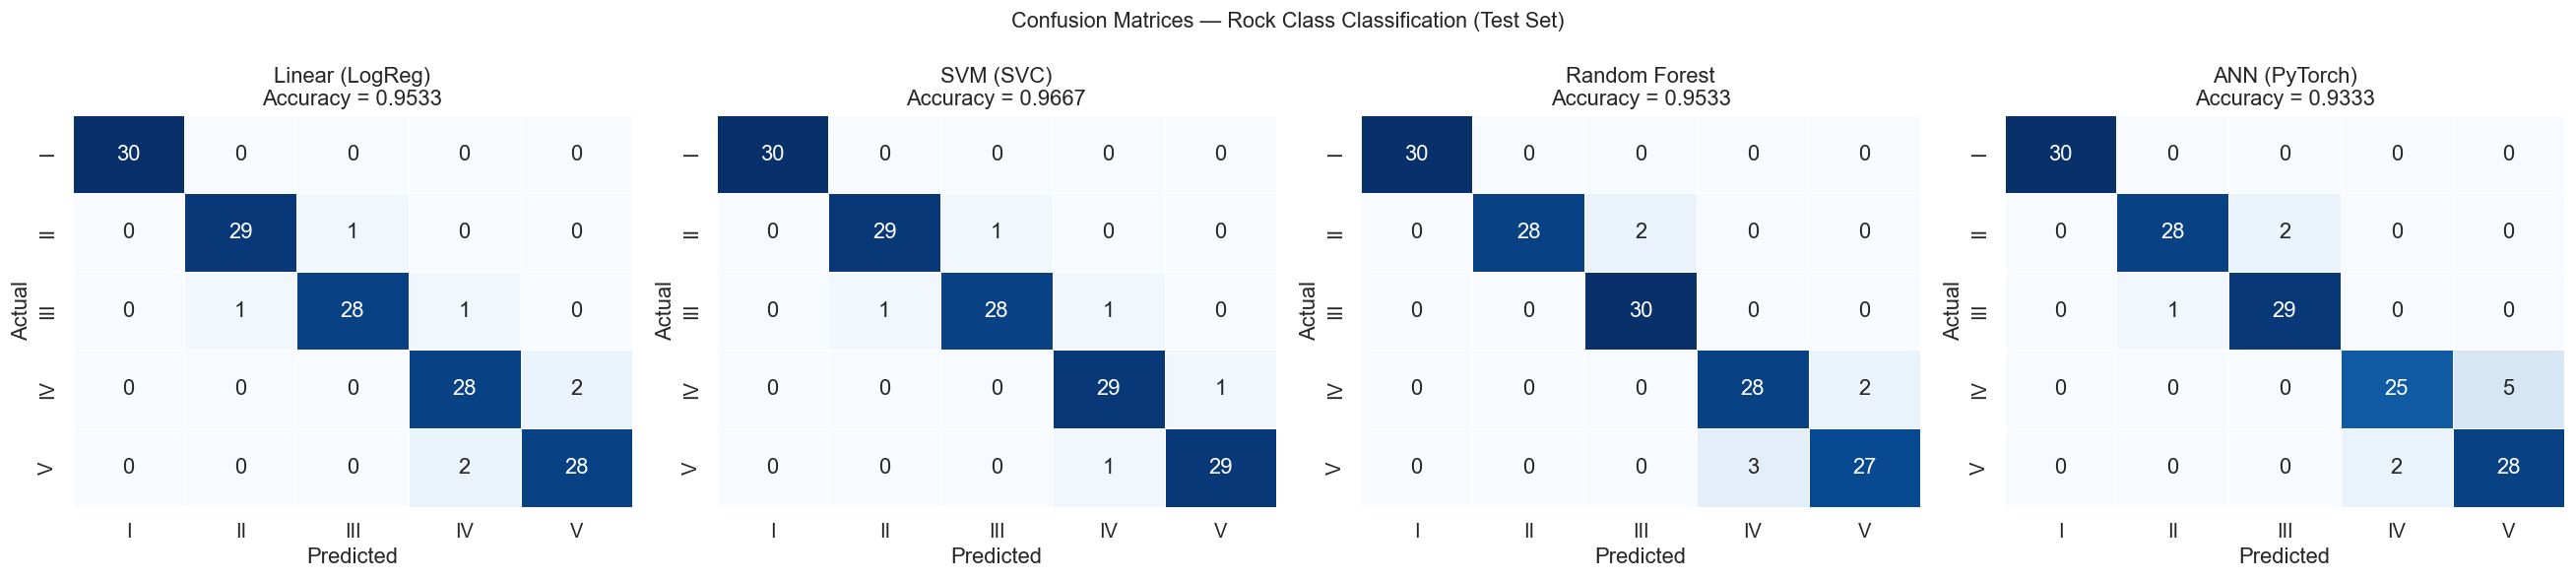

In [47]:
cls_preds = [
    ('Linear (LogReg)', lr_cls_pred_test),
    ('SVM (SVC)', svm_cls_pred_test),
    ('Random Forest', rf_cls_pred_test),
    ('ANN (PyTorch)', ann_cls_pred_test),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, preds) in zip(axes, cls_preds):
    cm  = confusion_matrix(y_cls_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                linewidths=0.5, linecolor='white', cbar=False)
    acc = accuracy_score(y_cls_test, preds)
    ax.set_title(f'{name}\nAccuracy = {acc:.4f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Rock Class Classification (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png')
plt.show()

In [ ]:
# all models struggle most at the II/III and III/IV boundaries — narrow RMR bands
# Class I and V are cleanest — extreme classes are easier to separate
# RF has the fewest off-diagonal errors overall
# ANN occasionally misclassifies Class II as Class I — consistent with shotcrete underestimation


In [49]:
print('Classification Reports — All Models')
for name, preds in cls_preds:
    print(f'\n{"="*55}')
    print(f'{name}')
    print('='*55)
    print(classification_report(y_cls_test, preds,
                                target_names=[f'Class {c}' for c in CLASS_ORDER]))

Classification Reports — All Models

Linear (LogReg)
              precision    recall  f1-score   support

     Class I       1.00      1.00      1.00        30
    Class II       0.97      0.97      0.97        30
   Class III       0.97      0.93      0.95        30
    Class IV       0.90      0.93      0.92        30
     Class V       0.93      0.93      0.93        30

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150


SVM (SVC)
              precision    recall  f1-score   support

     Class I       1.00      1.00      1.00        30
    Class II       0.97      0.97      0.97        30
   Class III       0.97      0.93      0.95        30
    Class IV       0.94      0.97      0.95        30
     Class V       0.97      0.97      0.97        30

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg 

---
## 12. Actual vs Predicted


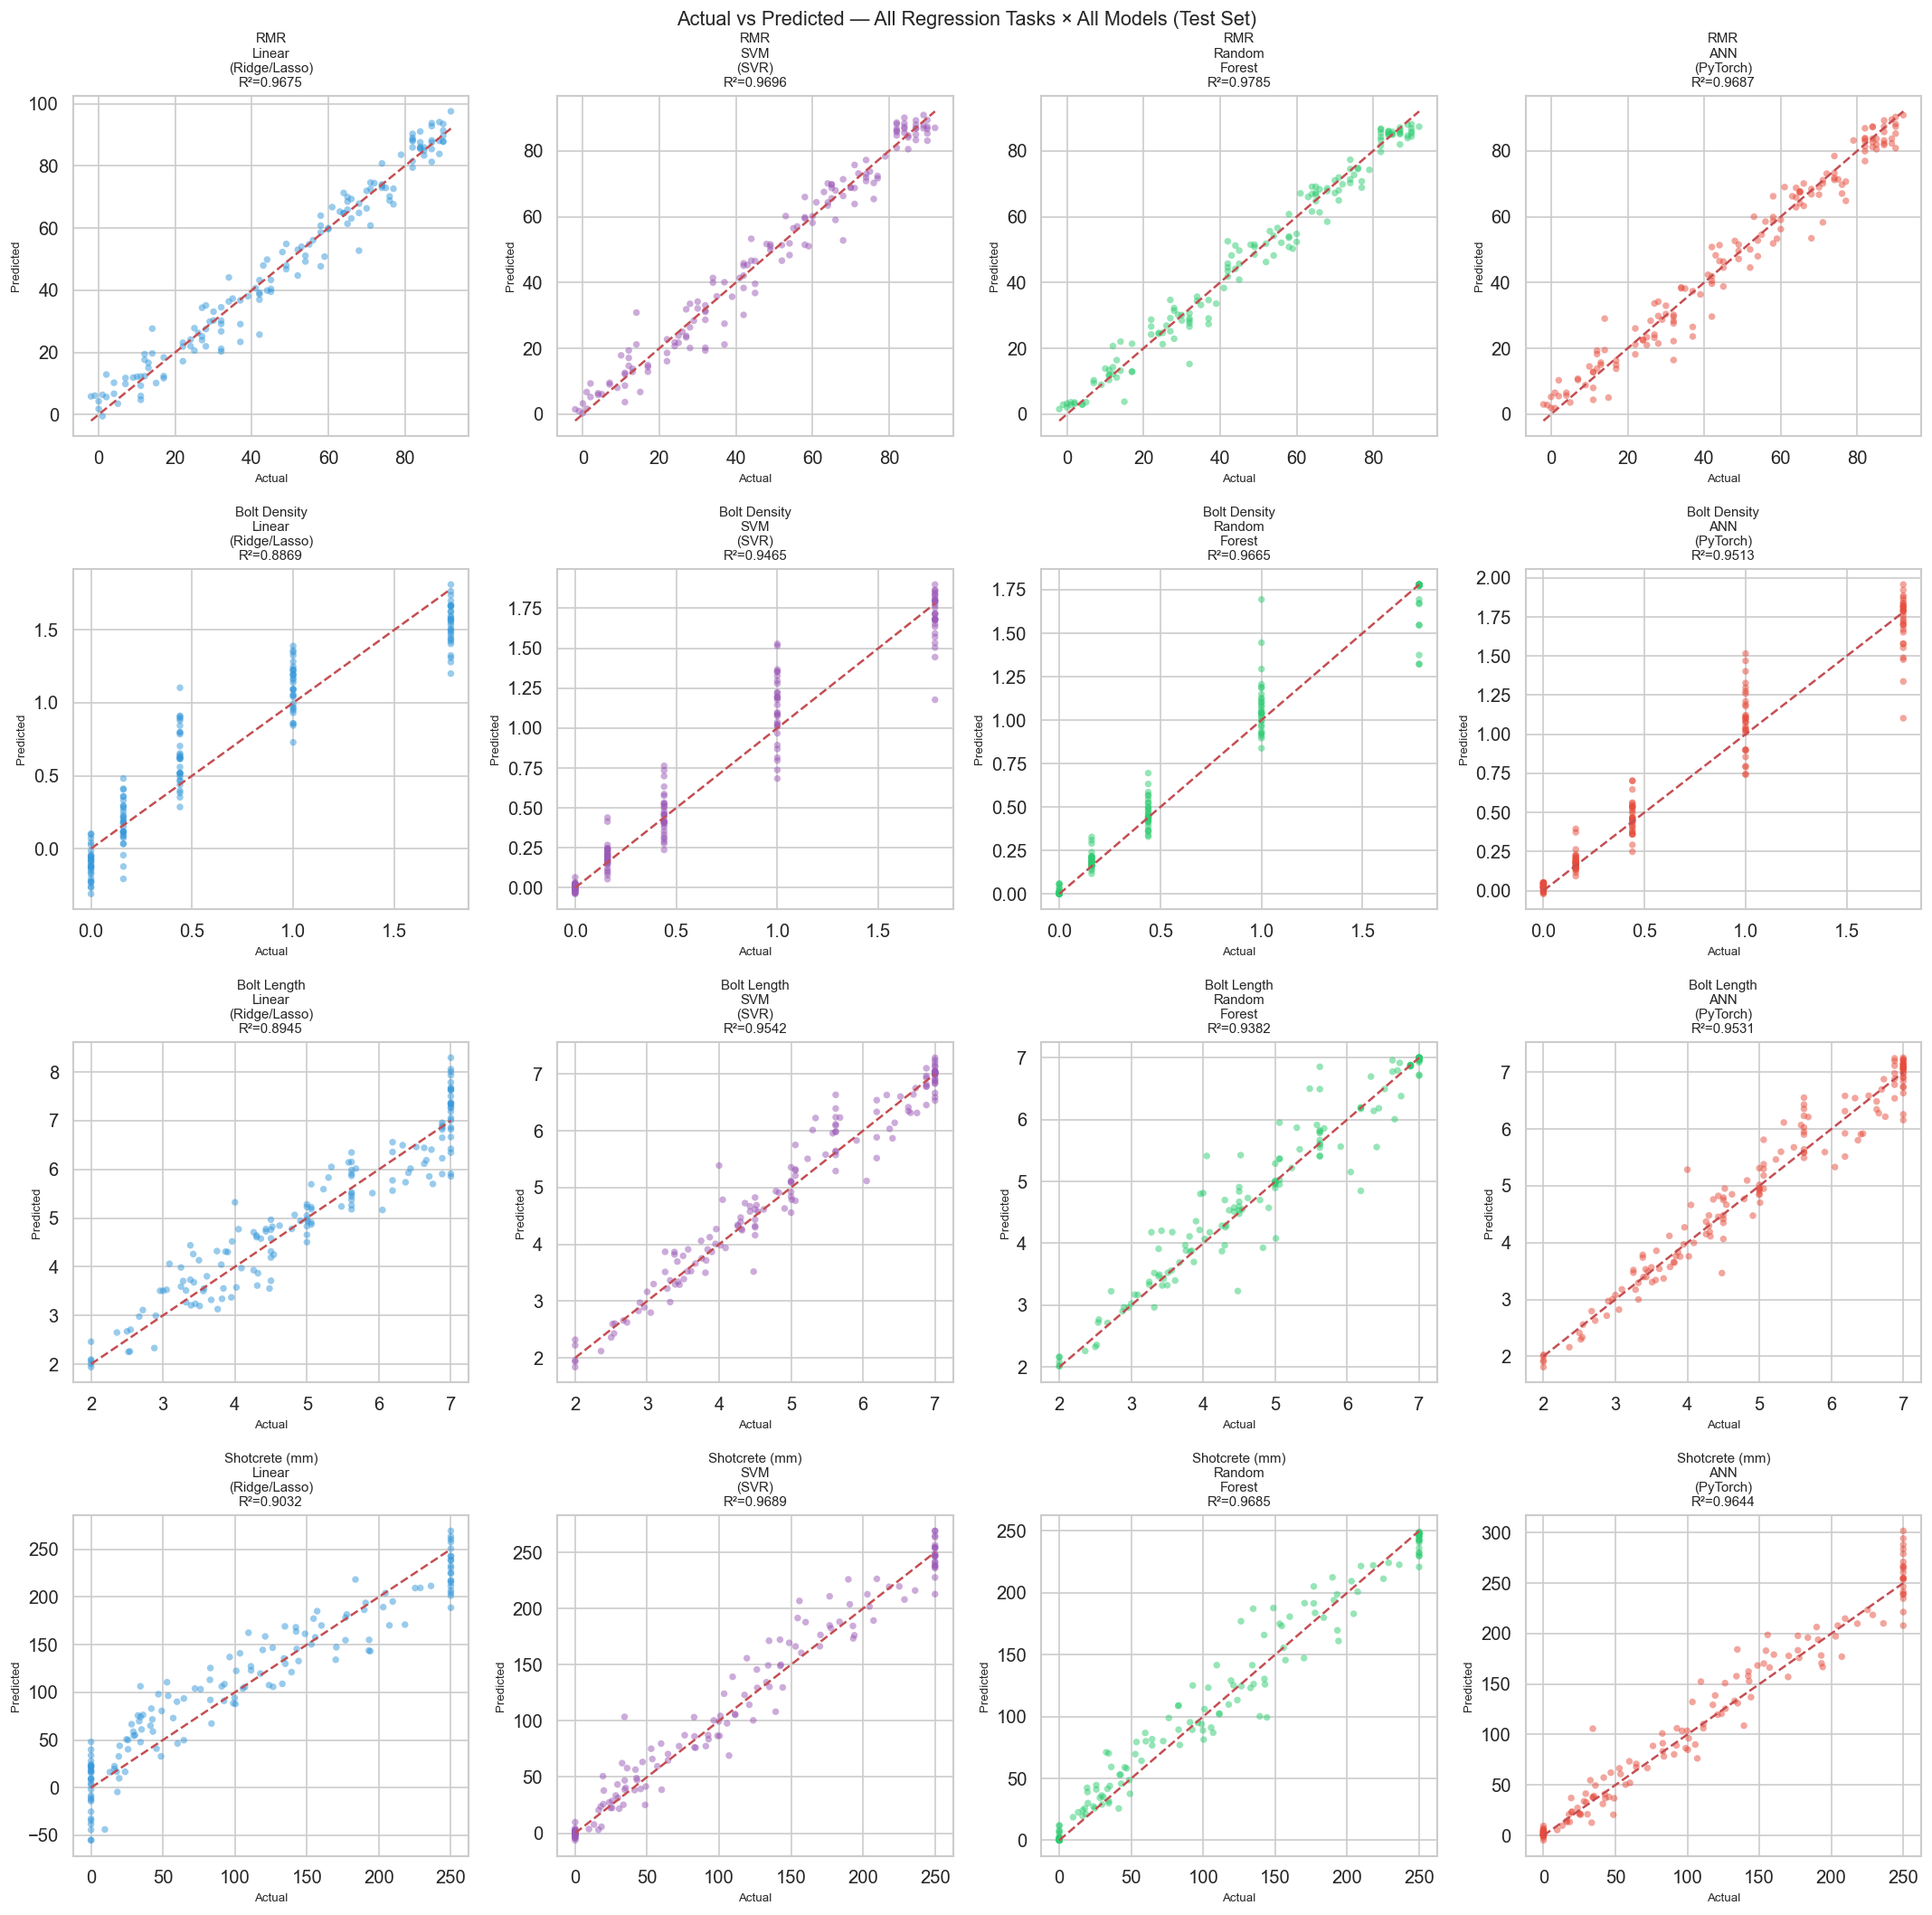

In [50]:
# Scatter plots for all 4 regression tasks × all models
reg_task_preds = [
    ('RMR',           y_rmr_test,  lr_rmr_pred_test,  svm_rmr_pred_test,  rf_rmr.predict(X_test), ann_rmr_pred_test),
    ('Bolt Density',  y_bd_test,   lr_bd_pred_test,   svm_bd_pred_test,   rf_bd.predict(X_test),  ann_bd_pred_test),
    ('Bolt Length',   y_bl_test,   lr_bl_pred_test,   svm_bl_pred_test,   rf_bl.predict(X_test),  ann_bl_pred_test),
    ('Shotcrete (mm)',y_sc_test,   lr_sc_pred_test,   svm_sc_pred_test,   rf_sc.predict(X_test),  ann_sc_pred_test),
]

model_names_reg = ['Linear\n(Ridge/Lasso)', 'SVM\n(SVR)', 'Random\nForest', 'ANN\n(PyTorch)']
model_colors    = ['#3498db', '#9b59b6', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(4, 4, figsize=(18, 18))

for row, (task_name, y_true, lr_p, svm_p, rf_p, ann_p) in enumerate(reg_task_preds):
    for col, (model_name, preds, color) in enumerate(
        zip(model_names_reg, [lr_p, svm_p, rf_p, ann_p], model_colors)):
        ax = axes[row, col]
        ax.scatter(y_true, preds, alpha=0.5, s=20, color=color, edgecolors='none')
        lo, hi = y_true.min(), y_true.max()
        ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')
        r2 = r2_score(y_true, preds)
        ax.set_title(f'{task_name}\n{model_name}\nR²={r2:.4f}', fontsize=9)
        ax.set_xlabel('Actual', fontsize=8); ax.set_ylabel('Predicted', fontsize=8)

plt.suptitle('Actual vs Predicted — All Regression Tasks × All Models (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_actual_vs_predicted.png')
plt.show()

---
## 13. Results Table


In [52]:
model_names = list(results.keys())
rows = []
for m in model_names:
    r = results[m]
    rows.append({
        'Model': m,
        'RMR R²': round(r['RMR_test']['R2'], 4),
        'RMR RMSE': round(r['RMR_test']['RMSE'], 4),
        'RMR MAE': round(r['RMR_test']['MAE'], 4),
        'Cls Acc': round(r['Class_test']['Accuracy'], 4),
        'Cls F1': round(r['Class_test']['F1_weighted'], 4),
        'BoltDen R²': round(r['BD_test']['R2'], 4),
        'BoltDen RMSE': round(r['BD_test']['RMSE'], 4),
        'BoltLen R²': round(r['BL_test']['R2'], 4),
        'BoltLen RMSE': round(r['BL_test']['RMSE'], 4),
        'Shotcrete R²': round(r['SC_test']['R2'], 4),
        'Shotcrete RMSE': round(r['SC_test']['RMSE'], 4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
comparison_df.to_csv('model_comparison.csv')
print('Saved: model_comparison.csv')
comparison_df

Saved: model_comparison.csv


,RMR R²,RMR RMSE,RMR MAE,Cls Acc,Cls F1,BoltDen R²,BoltDen RMSE,BoltLen R²,BoltLen RMSE,Shotcrete R²,Shotcrete RMSE
Model,,,,,,,,,,,
Linear Regression,0.9675,5.0785,3.9197,0.9533,0.9534,0.8869,0.2181,0.8945,0.4924,0.9032,27.4572
SVM,0.9696,4.9109,3.7431,0.9667,0.9667,0.9465,0.1500,0.9542,0.3243,0.9689,15.5600
Random Forest,0.9785,4.1282,3.1751,0.9533,0.9533,0.9665,0.1187,0.9382,0.3768,0.9685,15.6586


---
## 14. Model Comparison Plots


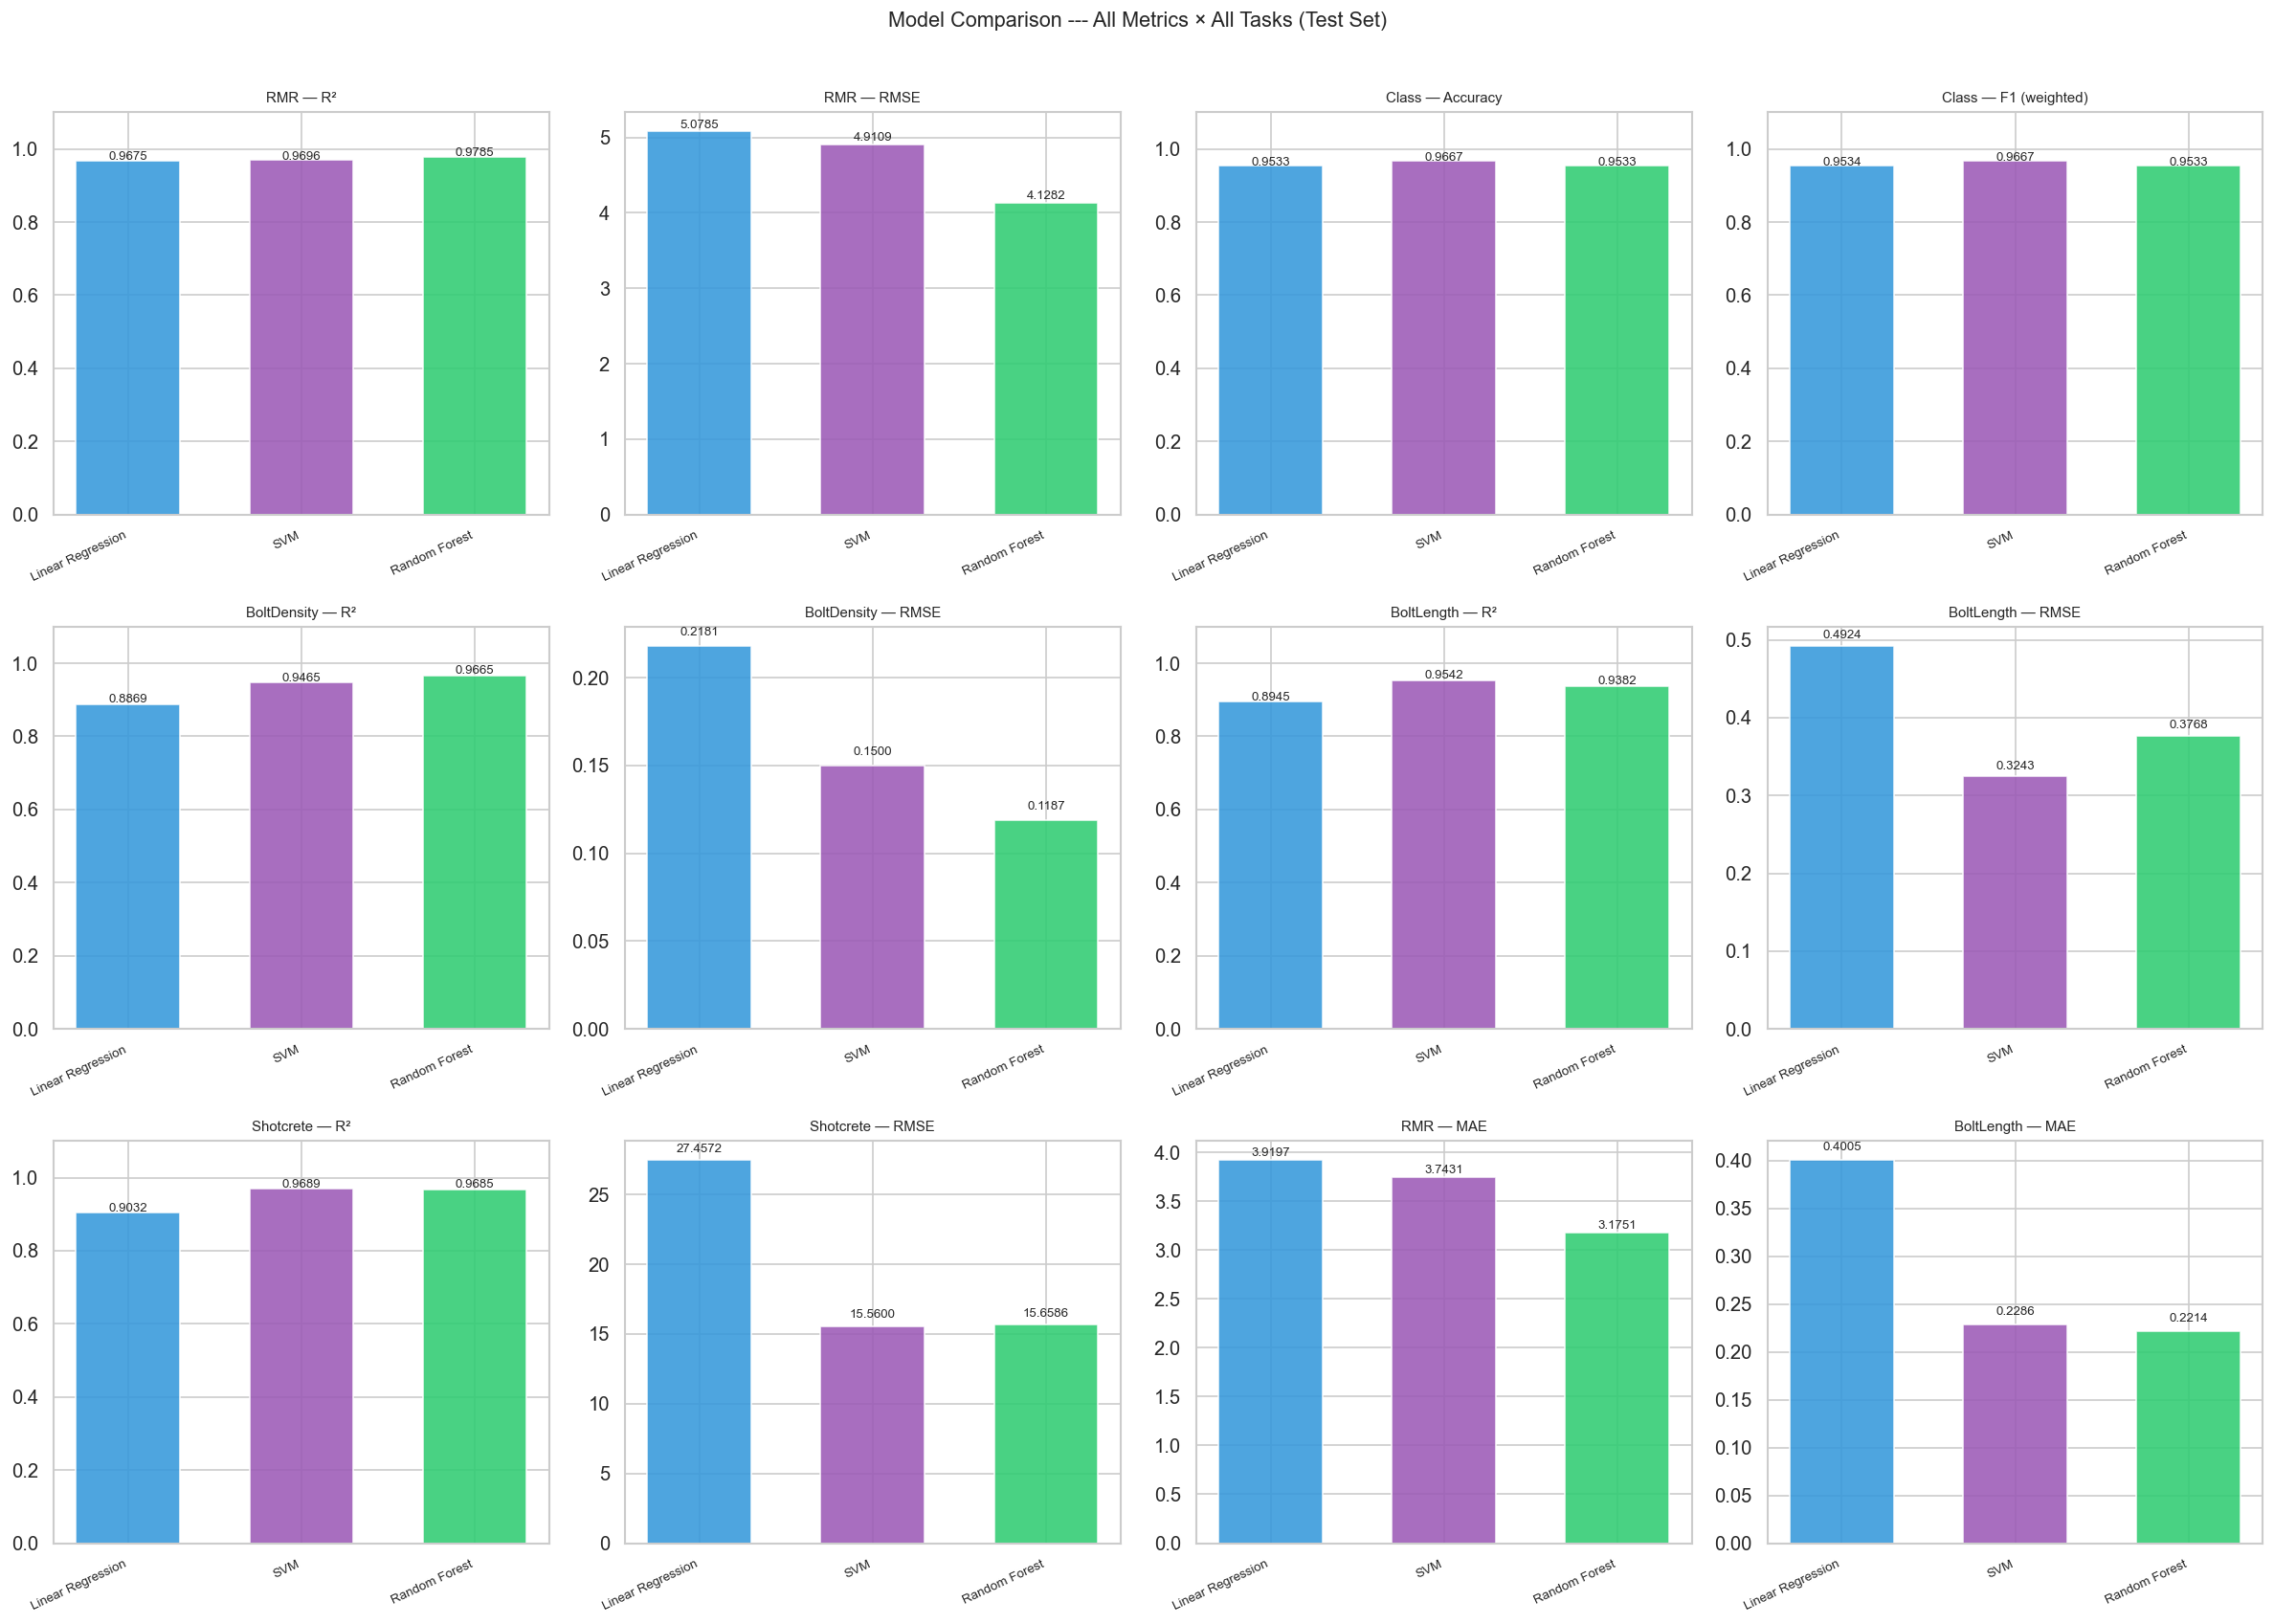

In [54]:
bar_colors = ['#3498db', '#9b59b6', '#2ecc71', '#e74c3c']
w = 0.6

fig, axes = plt.subplots(3, 4, figsize=(20, 14))

metrics_to_plot = [
    ('RMR_test','R2', 'RMR — R²', (0.0, 1.1)),
    ('RMR_test','RMSE', 'RMR — RMSE', None),
    ('Class_test', 'Accuracy', 'Class — Accuracy',(0.0, 1.1)),
    ('Class_test', 'F1_weighted','Class — F1 (weighted)',(0.0, 1.1)),
    ('BD_test', 'R2', 'BoltDensity — R²', (0.0, 1.1)),
    ('BD_test', 'RMSE', 'BoltDensity — RMSE', None),
    ('BL_test', 'R2', 'BoltLength — R²', (0.0, 1.1)),
    ('BL_test', 'RMSE', 'BoltLength — RMSE', None),
    ('SC_test', 'R2', 'Shotcrete — R²', (0.0, 1.1)),
    ('SC_test', 'RMSE', 'Shotcrete — RMSE', None),
    ('RMR_test', 'MAE', 'RMR — MAE', None),
    ('BL_test', 'MAE', 'BoltLength — MAE', None),
]

for ax, (key, sub, title, ylim) in zip(axes.flat, metrics_to_plot):
    vals = [results[m][key][sub] for m in model_names]
    ax.bar(model_names, vals, color=bar_colors, width=w, edgecolor='white', alpha=0.87)
    ax.set_title(title, fontsize=9)
    ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=8)
    if ylim: ax.set_ylim(*ylim)
    pad = (max(vals) - min(vals)) * 0.05 + 0.001
    for i, v in enumerate(vals):
        ax.text(i, v + pad, f'{v:.4f}', ha='center', fontsize=8)

plt.suptitle('Model Comparison --- All Metrics × All Tasks (Test Set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_model_comparison.png')
plt.show()

---
## 15. Save Models


In [55]:
import joblib

joblib.dump(best_lr_rmr, 'model_lr_rmr.pkl')
joblib.dump(lr_cls, 'model_lr_class.pkl')
joblib.dump(best_lr_bd, 'model_lr_bolt_density.pkl')
joblib.dump(best_lr_bl, 'model_lr_bolt_length.pkl')
joblib.dump(best_lr_sc, 'model_lr_shotcrete.pkl')

joblib.dump(svm_rmr, 'model_svm_rmr.pkl')
joblib.dump(svm_cls, 'model_svm_class.pkl')
joblib.dump(svm_bd, 'model_svm_bolt_density.pkl')
joblib.dump(svm_bl, 'model_svm_bolt_length.pkl')
joblib.dump(svm_sc, 'model_svm_shotcrete.pkl')

joblib.dump(rf_rmr, 'model_rf_rmr.pkl')
joblib.dump(rf_cls, 'model_rf_class.pkl')
joblib.dump(rf_bd, 'model_rf_bolt_density.pkl')
joblib.dump(rf_bl, 'model_rf_bolt_length.pkl')
joblib.dump(rf_sc, 'model_rf_shotcrete.pkl')

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')


joblib.dump(gs_svm_rmr, 'gs_svm_rmr.pkl')
joblib.dump(gs_svc, 'gs_svc.pkl')
joblib.dump(gs_rf_rmr, 'gs_rf_rmr.pkl')
joblib.dump(gs_rf_cls, 'gs_rf_cls.pkl')
joblib.dump(gs_log, 'gs_logistic.pkl')

# ANN weights 
for task_name, model in final_ann.items():
    torch.save(model.state_dict(), f'ext_model_ann_{task_name.lower()}.pth')

# ANN architecture info
ann_arch_info = {task: ARCH_CONFIGS[arch] for task, arch in best_arch.items()}
with open('ann_architectures.json', 'w') as f:
    json.dump(ann_arch_info, f, indent=2)

print('All models saved:')
print('Linear models : model_lr_*.pkl')
print('SVM models : model_svm_*.pkl')
print('RF models : model_rf_*.pkl')
print('ANN weights : model_ann_*.pth')
print('GridSearch objs : gs_*.pkl')
print('Scaler/Encoder : scaler.pkl, ext_label_encoder.pkl')
print('ANN arch info : ann_architectures.json')

All models saved:
Linear models : model_lr_*.pkl
SVM models : model_svm_*.pkl
RF models : model_rf_*.pkl
ANN weights : model_ann_*.pth
GridSearch objs : gs_*.pkl
Scaler/Encoder : scaler.pkl, ext_label_encoder.pkl
ANN arch info : ann_architectures.json


---
## 16. Summary


In [57]:
print('=' * 72)
print('FINAL SUMMARY — DATASET (Test Set Performance)')
print('=' * 72)

for task_key, task_label, metric_key, metric_name in [
    ('RMR_test', 'RMR Regression', 'R2', 'R²'),
    ('Class_test', 'Rock Class Classification','Accuracy',  'Acc'),
    ('BD_test', 'Bolt Density Regression',  'R2', 'R²'),
    ('BL_test', 'Bolt Length Regression', 'R2', 'R²'),
    ('SC_test', 'Shotcrete Regression', 'R2', 'R²'),
]:
    print(f'\n--- {task_label} ---')
    print(f'{"Model":<22} {metric_name:>8} {"RMSE/Acc":>10}')
    print('-' * 42)
    for m in model_names:
        val  = results[m][task_key][metric_key]
        val2 = results[m][task_key].get('RMSE', results[m][task_key].get('F1_weighted', float('nan')))
        print(f'{m:<22} {val:>8.4f} {val2:>10.4f}')

print(f'\n--- HYPERPARAMETER TUNING SUMMARY ---')
print(f'Ridge best alpha (RMR) : {ridge_rmr.alpha_:.4f}')
print(f'Lasso best alpha (RMR) : {lasso_rmr.alpha_:.4f}')
print(f'Best LogReg params : {gs_log.best_params_}')
print(f'Best SVR params (RMR) : {gs_svm_rmr.best_params_}')
print(f'Best SVC params : {gs_svc.best_params_}')
print(f'Best RF params (RMR) : {gs_rf_rmr.best_params_}')
print(f'Best RF params (BoltLength) : {gs_rf_bl.best_params_}')
print(f'Best RF params (Shotcrete) : {gs_rf_sc.best_params_}')
print()
print('Best ANN architectures per task:')
for task, arch in best_arch.items():
    hidden = ARCH_CONFIGS[arch]
    print(f' {task:<15}: {arch:<35} hidden={hidden}')

print(f'\n--- 5-FOLD CV (key results) ---')
for k in ['Ridge/Lasso — RMR','SVR — RMR','RF — RMR','ANN — RMR',
          'Ridge/Lasso — BoltLength','SVR — BoltLength','RF — BoltLength','ANN — BoltLength',
          'Ridge/Lasso — Shotcrete','SVR — Shotcrete','RF — Shotcrete','ANN — Shotcrete']:
    if k in all_cv:
        print(f'  {k:<40}: {all_cv[k]["mean"]:.4f} ± {all_cv[k]["std"]:.4f}')

print('\nFiles saved:')
print('Models : model_*.pkl  |  model_*.pth')
print('Results : model_comparison.csv')
print('Figures : fig*.png')
print('Arch : ann_architectures.json')
print('=' * 72)

FINAL SUMMARY — DATASET (Test Set Performance)

--- RMR Regression ---
Model                        R²   RMSE/Acc
------------------------------------------
Linear Regression        0.9675     5.0785
SVM                      0.9696     4.9109
Random Forest            0.9785     4.1282

--- Rock Class Classification ---
Model                       Acc   RMSE/Acc
------------------------------------------
Linear Regression        0.9533     0.9534
SVM                      0.9667     0.9667
Random Forest            0.9533     0.9533

--- Bolt Density Regression ---
Model                        R²   RMSE/Acc
------------------------------------------
Linear Regression        0.8869     0.2181
SVM                      0.9465     0.1500
Random Forest            0.9665     0.1187

--- Bolt Length Regression ---
Model                        R²   RMSE/Acc
------------------------------------------
Linear Regression        0.8945     0.4924
SVM                      0.9542     0.3243
Random Fores